In [4]:
%matplotlib inline

In [7]:
#format the book
import book_format
book_format.set_style()

If you've gotten this far I hope that you are thinking that the Kalman filter's fearsome reputation is somewhat undeserved. Sure, I hand waved some equations away, but I hope implementation has been fairly straightforward for you. The underlying concept is quite straightforward - take two measurements, or a measurement and a prediction, and choose the output to be somewhere between the two. If you believe the measurement more your guess will be closer to the measurement, and if you believe the prediction is more accurate your guess will lie closer to it. That's not rocket science (little joke - it is exactly this math that got Apollo to the moon and back!). 

读到这里，我希望你会觉得卡尔曼滤波器那可怕的声名有些名不副实。当然，我省略了一些公式，但实现起来应该相当简单。基本概念非常朴素：做两次测量，或者一次测量加一次预测，然后在两者之间取一个折中的结果——你若更信测量，估计就更靠近测量；你若更信预测，估计就更靠近预测。这可不是什么火箭科学（开个玩笑——恰恰是这套数学把阿波罗送上月球又带回来！）。

To be honest I have been choosing my problems carefully. For an arbitrary problem designing the Kalman filter matrices can be extremely difficult. I haven't been *too tricky*, though. Equations like Newton's equations of motion can be trivially computed for Kalman filter applications, and they make up the bulk of the kind of problems that we want to solve. 

说实话，我一直在精心挑选所举的问题。对任意问题而言，设计卡尔曼滤波器的矩阵可能非常困难；但我选的都不算*太难*。像牛顿运动方程这类方程很容易应用到卡尔曼滤波器上，而我们想解决的大部分问题都属于这一类。

I have illustrated the concepts with code and reasoning, not math. But there are topics that do require more mathematics than I have used so far. This chapter presents the math that you will need for the rest of the book.

我尽量用代码和推理来阐明概念，而非依赖数学。但有些主题确实需要比前面更多的数学准备。本章就补上全书后续所需的数学基础。


## Modeling a Dynamic System
## 7.1 对动态系统建模

A *dynamic system* is a physical system whose state (position, temperature, etc) evolves over time. Calculus is the math of changing values, so we use differential equations to model dynamic systems. Some systems cannot be modeled with differential equations, but we will not encounter those in this book.

*动态系统*是指状态（位置、温度等）随时间演变的物理系统。微积分研究的是变化量，因此我们借助微分方程来为动态系统建模。也有些系统无法用微分方程描述，但本书不会涉及。

Modeling dynamic systems is properly the topic of several college courses. To an extent there is no substitute for a few semesters of ordinary and partial differential equations followed by a graduate course in control system theory. If you are a hobbyist, or trying to solve one very specific filtering problem at work you probably do not have the time and/or inclination to devote a year or more to that education.

动态系统建模本身就是好几门大学课程的内容。某种程度上，几个学期的常微分方程、偏微分方程，再加一门研究生阶段的控制理论课，无可替代。但如果你只是爱好者，或者只想在工作中解决一个很具体的滤波问题，恐怕没有时间、也未必愿意花一年甚至更多时间去受这番训练。

Fortunately, I can present enough of the theory to allow us to create the system equations for many different Kalman filters. My goal is to get you to the stage where you can read a publication and understand it well enough to implement the algorithms. The background math is deep, but in practice we end up using a few simple techniques. 

好在我可以补足所需的理论，让你能为许多不同的卡尔曼滤波器写出系统方程。我的目标是把你带到这样的程度：能读懂相关文献，并充分理解到可以实现算法的地步。背后的数学很深，但在实践中，我们最终用到的只是少数几种简单技巧。

This is the longest section of pure math in this book. You will need to master everything in this section to understand the Extended Kalman filter (EKF), the most common nonlinear filter. I do cover more modern filters that do not require as much of this math. You can choose to skim now, and come back to this if you decide to learn the EKF.

这是全书篇幅最长的纯数学部分。要理解扩展卡尔曼滤波器 (EKF，最常见的非线性滤波器)，你需要掌握本章的全部内容。我也介绍了对数学要求没那么高的更现代滤波器。你现在可以选择略读；如果决定学 EKF，再回来细看。

We need to start by understanding the underlying equations and assumptions that the Kalman filter uses. We are trying to model real world phenomena, so what do we have to consider?

我们得先弄清卡尔曼滤波器所用的基本方程和假设。既然是要为现实世界的现象建模，那我们该考虑哪些因素？

Each physical system has a process. For example, a car traveling at a certain velocity goes so far in a fixed amount of time, and its velocity varies as a function of its acceleration. We describe that behavior with the well known Newtonian equations that we learned in high school.

每个物理系统都有一个过程。例如，一辆以某速度行驶的汽车，在固定时间内走的距离可以算出来，而它的速度又随加速度变化。我们用高中就学过的牛顿方程来描述这种行为。

$$
\begin{aligned}
v&=at\\
x &= \frac{1}{2}at^2 + v_0t + x_0
\end{aligned}
$$

Once we learned calculus we saw them in this form:

由微积分知识可得：

$$ \mathbf v = \frac{d \mathbf x}{d t}, 
\quad \mathbf a = \frac{d \mathbf v}{d t} = \frac{d^2 \mathbf x}{d t^2}
$$

A typical automobile tracking problem would have you compute the distance traveled given a constant velocity or acceleration, as we did in previous chapters. But, of course we know this is not all that is happening. No car travels on a perfect road. There are bumps, wind drag, and hills that raise and lower the speed. The suspension is a mechanical system with friction and imperfect springs.

典型的汽车跟踪问题会让你在速度或加速度恒定时计算行驶距离，正如前几章所做的那样。不过，当然，我们知道实际情况并不止于此。没有汽车会行驶在完美的道路上，颠簸、风阻和坡度都会使速度升高或降低。悬架也是一个具有摩擦和不完美弹簧的机械系统。

Perfectly modeling a system is impossible except for the most trivial problems. We are forced to make a simplification. At any time $t$ we say that the true state (such as the position of our car) is the predicted value from the imperfect model plus some unknown *process noise*:

除了最简单的问题，完美建模是不可能的。我们不得不做简化：在任何时刻 $t$，把真实状态（比如汽车的位置）视为不完美模型给出的预测值，再加上某种未知的*过程噪声*：

$$
x(t) = x_{pred}(t) + noise(t)
$$

This is not meant to imply that $noise(t)$ is a function that we can derive analytically. It is merely a statement of fact - we can always describe the true value as the predicted value  plus the process noise. "Noise" does not imply random events. If we are tracking a thrown ball in the atmosphere, and our model assumes the ball is in a vacuum, then the effect of air drag is process noise in this context.

这并不是说 $noise(t)$ 是一个能解析推导出来的函数，它只是陈述一个事实：真实值总可以写成预测值加过程噪声。“噪声”未必指随机事件——例如在大气中跟踪一个抛出的球，而我们的模型假设球在真空中，此时空气阻力的影响就是过程噪声。

In the next section we will learn techniques to convert a set of higher order differential equations into a set of first-order differential equations.  After the conversion the model of the system without noise is:

下一节我们将学习如何把一组高阶微分方程化为一组一阶微分方程。转换后，不含噪声的系统模型为：

$$ \dot{\mathbf x} = \mathbf{Ax}$$

$\mathbf A$ is known as the *systems dynamics matrix* as it describes the dynamics of the system. Now we need to model the noise. We will call that $\mathbf w$, and add it to the equation. 

$\mathbf A$ 称为*系统动力学矩阵*，因为它描述系统的动力学。接下来需要对噪声建模，我们把它记作 $\mathbf w$ 并加进方程。

$$ \dot{\mathbf x} = \mathbf{Ax} + \mathbf w$$

$\mathbf w$ may strike you as a poor choice for the name, but you will soon see that the Kalman filter assumes *white* noise.

$\mathbf w$ 这个名字也许让你觉得取得不好，但你很快就会看到，卡尔曼滤波器假设的是*白*噪声。

Finally, we need to consider any inputs into the system. We assume an input $\mathbf u$, and that there exists a linear model that defines how that input changes the system. For example, pressing the accelerator in your car makes it accelerate, and gravity causes balls to fall. Both are control inputs. We will need a matrix $\mathbf B$ to convert $u$ into the effect on the system. We add that into our equation:

最后还要考虑系统的输入。设输入为 $\mathbf u$，并假定有一个线性模型描述该输入如何改变系统。例如踩下汽车油门会使车加速，重力则让球下落，两者都是控制输入。我们需要一个矩阵 $\mathbf B$，把 $u$ 转换成对系统的影响，并将其加入方程：

$$ \dot{\mathbf x} = \mathbf{Ax} + \mathbf{Bu} + \mathbf{w}$$

And that's it. That is one of the equations that Dr. Kalman set out to solve, and he found an optimal estimator if we assume certain properties of $\mathbf w$.

就是这样。这是 Kalman 博士着手求解的方程之一；如果对 $\mathbf w$ 假定具有某些性质，他便找到了最优估计器。


## State-Space Representation of Dynamic Systems
## 7.2 动态系统的状态空间表示

We've derived the equation

我们已经推导出方程

$$ \dot{\mathbf x} = \mathbf{Ax}+ \mathbf{Bu} + \mathbf{w}$$

However, we are not interested in the derivative of $\mathbf x$, but in $\mathbf x$ itself. Ignoring the noise for a moment, we want an equation that recursively finds the value of $\mathbf x$ at time $t_k$ in terms of $\mathbf x$ at time $t_{k-1}$:

但我们关心的不是 $\mathbf x$ 的导数，而是 $\mathbf x$ 本身。暂时忽略噪声，我们需要一个方程，能由时刻 $t_{k-1}$ 的 $\mathbf x$ 递推出时刻 $t_k$ 的 $\mathbf x$：

$$\mathbf x(t_k) = \mathbf F(\Delta t)\mathbf x(t_{k-1}) + \mathbf B(t_k)\mathbf u (t_k)$$

Convention allows us to write $\mathbf x(t_k)$ as $\mathbf x_k$, which means the 
the value of $\mathbf x$ at the $k^{th}$ value of $t$.

按惯例，可把 $\mathbf x(t_k)$ 简写为 $\mathbf x_k$，即 $\mathbf x$ 在第 $k$ 个时刻的取值。

$$\mathbf x_k = \mathbf{Fx}_{k-1} + \mathbf B_k\mathbf u_k$$

$\mathbf F$ is the familiar *state transition matrix*, named due to its ability to transition the state's value between discrete time steps. It is very similar to the system dynamics matrix $\mathbf A$. The difference is that $\mathbf A$ models a set of linear differential equations, and is continuous. $\mathbf F$ is discrete, and represents a set of linear equations (not differential equations) which transitions $\mathbf x_{k-1}$ to $\mathbf x_k$ over a discrete time step $\Delta t$. 

$\mathbf F$ 就是熟悉的*状态转移矩阵*，名字来自它能在离散时间步之间转移状态值。它与系统动力学矩阵 $\mathbf A$ 很相似，区别在于：$\mathbf A$ 描述的是一组连续时间的线性微分方程；而 $\mathbf F$ 是离散的，描述的是一组线性方程（不是微分方程），它在离散时间步 $\Delta t$ 上把 $\mathbf x_{k-1}$ 变为 $\mathbf x_k$。

Finding this matrix is often quite difficult. The equation $\dot x = v$ is the simplest possible differential equation and we trivially integrate it as:

求出这个矩阵通常很难。而 $\dot x = v$ 是最简单的微分方程，直接积分即可：

$$ \int\limits_{x_{k-1}}^{x_k}  \mathrm{d}x = \int\limits_{0}^{\Delta t} v\, \mathrm{d}t $$
$$x_k-x_{k-1} = v \Delta t$$
$$x_k = v \Delta t + x_{k-1}$$

This equation is *recursive*: we compute the value of $x$ at time $k$ based on its value at time $k-1$. This recursive form enables us to represent the system (process model) in the form required by the Kalman filter:

这个方程是*递归的*：由 $x$ 在时刻 $k-1$ 的值算出它在时刻 $k$ 的值。正是这种递归形式让我们能把系统（过程模型）写成卡尔曼滤波器所需的形式：

$$\begin{aligned}
\mathbf x_k &= \mathbf{Fx}_{k-1}  \\
&= \begin{bmatrix} 1 & \Delta t \\ 0 & 1\end{bmatrix}
\begin{bmatrix}x_{k-1} \\ \dot x_{k-1}\end{bmatrix}
\end{aligned}$$

We can do that only because $\dot x = v$ is simplest differential equation possible. Almost all other in physical systems result in more complicated differential equation which do not yield to this approach. 

之所以能这样做，只是因为 $\dot x = v$ 是最简单的微分方程。几乎所有其他物理系统都会导出更复杂的微分方程，无法如此处理。

*State-space* methods became popular around the time of the Apollo missions, largely due to the work of Dr. Kalman. The idea is simple. Model a system with a set of  $n^{th}$-order differential equations. Convert them into an equivalent set of first-order differential equations. Put them into the vector-matrix form used in the previous section: $\dot{\mathbf x} = \mathbf{Ax} + \mathbf{Bu}$. Once in this form we use of several techniques to convert these linear differential equations into the recursive equation:

*状态空间*方法在阿波罗计划期间开始流行，主要归功于 Kalman 的工作。其思路很简单：先用一组 $n$ 阶微分方程为系统建模；把它们化成等价的 $n$ 个一阶微分方程；再写成上一节的向量矩阵形式 $\dot{\mathbf x} = \mathbf{Ax} + \mathbf{Bu}$。一旦化为这种形式，就可以用若干技术把这些线性微分方程转成递归方程：

$$ \mathbf x_k = \mathbf{Fx}_{k-1} + \mathbf B_k\mathbf u_k$$

Some books call the state transition matrix the *fundamental matrix*. Many use $\mathbf \Phi$ instead of $\mathbf F$. Sources based heavily on control theory tend to use these forms.

有些书把状态转移矩阵称为*基本矩阵*，也有很多人用 $\mathbf \Phi$ 而不用 $\mathbf F$，控制理论方面的大量资料习惯采用这类记号。

These are called *state-space* methods because we are expressing the solution of the differential equations in terms of the system state.

这些方法被称为*状态空间*方法，因为我们是用系统状态来表示微分方程的解。


### Forming First Order Equations from Higher Order Equations
### 由高阶方程构造一阶方程

Many models of physical systems require second or higher order differential equations with control input $u$:

许多物理系统的模型会用到带控制输入 $u$ 的二阶或更高阶微分方程：

$$a_n \frac{d^ny}{dt^n} + a_{n-1} \frac{d^{n-1}y}{dt^{n-1}} +  \dots + a_2 \frac{d^2y}{dt^2} + a_1 \frac{dy}{dt} + a_0 = u$$

State-space methods require first-order equations. Any higher order system of equations can be reduced to first-order by defining extra variables for the derivatives and then solving. 

状态空间方法要求一阶方程。任何高阶方程组，都可以通过为各阶导数引入额外变量并求解，化为一阶方程组。

Let's do an example. Given the system $\ddot{x} - 6\dot x + 9x = u$ find the equivalent first order equations. I've used the dot notation for the time derivatives for clarity.

举个例子。给定系统 $\ddot{x} - 6\dot x + 9x = u$，求其等价的一阶方程。为清楚起见，这里用点号表示对时间的导数。

The first step is to isolate the highest order term onto one side of the equation.

第一步是把最高阶项单独留在等式一侧。

$$\ddot{x} = 6\dot x - 9x + u$$

We define two new variables:

我们定义两个新变量：

$$\begin{aligned} x_1(t) &= x \\
x_2(t) &= \dot x
\end{aligned}$$

Now we will substitute these into the original equation and solve. The solution yields a set of first-order equations in terms of these new variables. It is conventional to drop the $(t)$ for notational convenience.

把它们代入原方程再求解，就能用这些新变量表示出一组一阶方程。为简便起见，通常省去 $(t)$。

We know that $\dot x_1 = x_2$ and that $\dot x_2 = \ddot{x}$. Therefore

我们知道 $\dot x_1 = x_2$ 和 $\dot x_2 = \ddot{x}$。所以

$$\begin{aligned}
\dot x_2 &= \ddot{x} \\
         &= 6\dot x - 9x + u\\
         &= 6x_2-9x_1 + u
\end{aligned}$$

Therefore our first-order system of equations is

因此我们的一阶方程组是

$$\begin{aligned}\dot x_1 &= x_2 \\
\dot x_2 &= 6x_2-9x_1 + u\end{aligned}$$

If you practice this a bit you will become adept at it. Isolate the highest term, define a new variable and its derivatives, and then substitute.

如果你稍微练习一下，你就会熟练掌握它。隔离最高项，定义一个新变量及其导数，然后替换。


### First Order Differential Equations In State-Space Form
### 状态空间形式的一阶微分方程

Substituting the newly defined variables from the previous section:

替换上一节中新定义的变量：

$$\frac{dx_1}{dt} = x_2,\,  
\frac{dx_2}{dt} = x_3, \, ..., \, 
\frac{dx_{n-1}}{dt} = x_n$$

into the first order equations yields: 

代入一阶方程可得：

$$\frac{dx_n}{dt} = \frac{1}{a_n}\sum\limits_{i=0}^{n-1}a_ix_{i+1} + \frac{1}{a_n}u
$$

Using vector-matrix notation we have:

使用向量矩阵表示法，我们有：

$$\begin{bmatrix}\frac{dx_1}{dt} \\ \frac{dx_2}{dt} \\ \vdots \\ \frac{dx_n}{dt}\end{bmatrix} = 
\begin{bmatrix}\dot x_1 \\ \dot x_2 \\ \vdots \\ \dot x_n\end{bmatrix}=
\begin{bmatrix}0 & 1 & 0 &\cdots & 0 \\
0 & 0 & 1 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
-\frac{a_0}{a_n} & -\frac{a_1}{a_n} & -\frac{a_2}{a_n} & \cdots & -\frac{a_{n-1}}{a_n}\end{bmatrix}
\begin{bmatrix}x_1 \\ x_2 \\ \vdots \\ x_n\end{bmatrix} + 
\begin{bmatrix}0 \\ 0 \\ \vdots \\ \frac{1}{a_n}\end{bmatrix}u$$

which we then write as $\dot{\mathbf x} = \mathbf{Ax} + \mathbf{B}u$.

然后我们写成 $\dot{\mathbf x} = \mathbf{Ax} + \mathbf{B}u$.


### Finding the Fundamental Matrix for Time Invariant Systems
### 求时不变系统的基本矩阵

We express the system equations in state-space form with

我们用状态空间形式表示系统方程

$$ \dot{\mathbf x} = \mathbf{Ax}$$

where $\mathbf A$ is the system dynamics matrix, and want to find the *fundamental matrix* $\mathbf F$ that propagates the state $\mathbf x$ over the interval $\Delta t$ with the equation

其中 $\mathbf A$ 是系统动力学矩阵，并且想要找到*基本矩阵* $\mathbf F$，使它以方程在区间 $\Delta t$ 上传播状态 $\mathbf x$：

$$\begin{aligned}
\mathbf x(t_k) = \mathbf F(\Delta t)\mathbf x(t_{k-1})\end{aligned}$$

In other words, $\mathbf A$ is a set of continuous differential equations, and we need $\mathbf F$ to be a set of discrete linear equations that computes the change in $\mathbf A$ over a discrete time step.

换句话说，$\mathbf A$ 是一组连续微分方程，我们需要 $\mathbf F$ 是一组离散线性方程，用于计算在离散时间步上 $\mathbf A$ 的变化。

It is conventional to drop the $t_k$ and $(\Delta t)$ and use the notation

按照惯例，去掉 $t_k$ 和 $(\Delta t)$ 并使用符号

$$\mathbf x_k = \mathbf {Fx}_{k-1}$$

Broadly speaking there are three common ways to find this matrix for Kalman filters. The technique most often used is the matrix exponential. Linear Time Invariant Theory, also known as LTI System Theory, is a second technique. Finally, there are numerical techniques. You may know of others, but these three are what you will most likely encounter in the Kalman filter literature and praxis.

一般来说，有三种常见的方法可以找到卡尔曼滤波器的这个矩阵。最常用的技术是矩阵指数。线性时不变理论，也称为 LTI 系统理论，是第二种技术。最后，还有数值技术。你可能知道其他方法，但这三个是你在卡尔曼滤波器文献和实践中最有可能遇到的。


### The Matrix Exponential
### 矩阵指数

The solution to the equation $\frac{dx}{dt} = kx$ can be found by:

方程 $\frac{dx}{dt} = kx$ 的解可以通过以下方式找到：

$$\begin{gathered}\frac{dx}{dt} = kx \\
\frac{dx}{x} = k\, dt \\
\int \frac{1}{x}\, dx = \int k\, dt \\
\log x = kt + c \\
x = e^{kt+c} \\
x = e^ce^{kt} \\
x = c_0e^{kt}\end{gathered}$$

When $t=0$, $x=x_0$. Substitute these to equation above.

当 $t=0$ 时，$x=x_0$。将这些代入上式。

$$\begin{gathered}x_0 = c_0e^{k(0)} \\
x_0 = c_01 \\
x_0 = c_0 \\
x = x_0e^{kt}\end{gathered}$$

Using similar math, the solution to the first-order equation 

使用类似的数学，一阶方程的解为

$$\dot{\mathbf x} = \mathbf{Ax} ,\, \, \, \mathbf x(0) = \mathbf x_0$$

where $\mathbf A$ is a constant matrix, is

其中 $\mathbf A$ 是一个常数矩阵，其解为

$$\mathbf x = e^{\mathbf At}\mathbf x_0$$

Substituting $F = e^{\mathbf At}$, we can write 

代入 $F = e^{\mathbf At}$，我们可以写成

$$\mathbf x_k = \mathbf F\mathbf x_{k-1}$$

which is the form we are looking for! We have reduced the problem of finding the fundamental matrix to one of finding the value for $e^{\mathbf At}$.

这正是我们正在寻找的形式！我们将求基本矩阵的问题简化为求 $e^{\mathbf At}$ 的值。

$e^{\mathbf At}$ is known as the [matrix exponential](https://en.wikipedia.org/wiki/Matrix_exponential). It can be computed with this power series:

$e^{\mathbf At}$ 被称为[矩阵指数](https://en.wikipedia.org/wiki/Matrix_exponential)。可以用这个幂级数计算：

$$e^{\mathbf At} = \mathbf{I} + \mathbf{A}t  + \frac{(\mathbf{A}t)^2}{2!} + \frac{(\mathbf{A}t)^3}{3!} + ... $$

That series is found by doing a Taylor series expansion of $e^{\mathbf At}$, which I will not cover here.

该级数是通过对 $e^{\mathbf At}$ 进行泰勒级数展开得到的，这里我不会介绍。

Let's use this to find the solution to Newton's equations. Using $v$ as a substitution for $\dot x$, and assuming constant velocity we get the linear matrix-vector form 

让我们用它来找到牛顿方程的解。使用 $v$ 代替 $\dot x$，并假设速度恒定，我们得到线性矩阵向量形式

$$\begin{bmatrix}\dot x \\ \dot v\end{bmatrix} =\begin{bmatrix}0&1\\0&0\end{bmatrix} \begin{bmatrix}x \\ v\end{bmatrix}$$

This is a first order differential equation, so we can set $\mathbf{A}=\begin{bmatrix}0&1\\0&0\end{bmatrix}$ and solve the following equation. I have substituted the interval $\Delta t$ for $t$ to emphasize that the fundamental matrix is discrete:

这是一个一阶微分方程，因此我们可以设定 $\mathbf{A}=\begin{bmatrix}0&1\\0&0\end{bmatrix}$ 并求解以下方程。我已将 $t$ 替换为区间 $\Delta t$，以强调基本矩阵是离散的：

$$\mathbf F = e^{\mathbf A\Delta t} = \mathbf{I} + \mathbf A\Delta t  + \frac{(\mathbf A\Delta t)^2}{2!} + \frac{(\mathbf A\Delta t)^3}{3!} + ... $$

If you perform the multiplication you will find that $\mathbf{A}^2=\begin{bmatrix}0&0\\0&0\end{bmatrix}$, which means that all higher powers of $\mathbf{A}$ are also $\mathbf{0}$. Thus we get an exact answer without an infinite number of terms:

如果你执行乘法，会发现 $\mathbf{A}^2=\begin{bmatrix}0&0\\0&0\end{bmatrix}$，这意味着 $\mathbf{A}$ 的所有高次幂也是 $\mathbf{0}$。因此，我们得到了一个无需无穷多项的精确答案：

$$
\begin{aligned}
\mathbf F &=\mathbf{I} + \mathbf A \Delta t + \mathbf{0} \\
&= \begin{bmatrix}1&0\\0&1\end{bmatrix} + \begin{bmatrix}0&1\\0&0\end{bmatrix}\Delta t\\
&= \begin{bmatrix}1&\Delta t\\0&1\end{bmatrix}
\end{aligned}$$

We plug this into $\mathbf x_k= \mathbf{Fx}_{k-1}$ to get

我们把它代入 $\mathbf x_k= \mathbf{Fx}_{k-1}$ 得到

$$
\begin{aligned}
x_k &=\begin{bmatrix}1&\Delta t\\0&1\end{bmatrix}x_{k-1}
\end{aligned}$$

You will recognize this as the matrix we derived analytically for the constant velocity Kalman filter in the **Multivariate Kalman Filter** chapter.

你会认出这是我们在**多元卡尔曼滤波器**一章中为恒速卡尔曼滤波器解析推导出的矩阵。

SciPy's linalg module includes a routine `expm()` to compute the matrix exponential. It does not use the Taylor series method, but the [Padé Approximation](https://en.wikipedia.org/wiki/Pad%C3%A9_approximant). There are many (at least 19) methods to compute the matrix exponential, and all suffer from numerical difficulties[1]. You should be aware of the problems, especially when $\mathbf A$ is large. If you search for "pade approximation matrix exponential" you will find many publications devoted to this problem. 

SciPy 的 linalg 模块包括一个例程 `expm()` 来计算矩阵指数。它不使用泰勒级数方法，而是使用 [Padé Approximation](https://en.wikipedia.org/wiki/Pad%C3%A9_approximant)。计算矩阵指数的方法有很多（至少 19 种），并且都存在数值困难[1]。你应该意识到这些问题，尤其是当 $\mathbf A$ 很大时。如果你搜索“pade approximation matrix exponential”，你会发现许多专门针对此问题的出版物。

In practice this may not be of concern to you as for the Kalman filter we normally just take the first two terms of the Taylor series. But don't assume my treatment of the problem is complete and run off and try to use this technique for other problem without doing a numerical analysis of the performance of this technique. Interestingly, one of the favored ways of solving $e^{\mathbf At}$ is to use a generalized ode solver. In other words, they do the opposite of what we do - turn $\mathbf A$ into a set of differential equations, and then solve that set using numerical techniques! 

在实践中，这可能并不需要你担心，因为对于卡尔曼滤波器，我们通常只取泰勒级数的前两项。但不要以为我对这个问题的处理是完整的，就在没有对这种技术的性能做数值分析的情况下，转而尝试将其用于其他问题。有趣的是，求解 $e^{\mathbf At}$ 的一种常用方法是使用通用 ODE 求解器。换句话说，他们的做法与我们的相反：将 $\mathbf A$ 转化为一组微分方程，然后使用数值技术求解该方程组！

Here is an example of using `expm()` to solve $e^{\mathbf At}$.

这是一个使用 `expm()` 求解 $e^{\mathbf At}$ 的示例。


In [8]:
import numpy as np
from scipy.linalg import expm

dt = 0.1
A = np.array([[0, 1], 
              [0, 0]])
expm(A*dt)

array([[1. , 0.1],
       [0. , 1. ]])

### Time Invariance
### 时不变性

If the behavior of the system depends on time we can say that a dynamic system is described by the first-order differential equation

如果系统的行为取决于时间，我们可以说动态系统由一阶微分方程描述

$$ g(t) = \dot x$$

However, if the system is *time invariant* the equation is of the form:

但是，如果系统是*时不变的*，则方程的形式为：

$$ f(x) = \dot x$$

What does *time invariant* mean? Consider a home stereo. If you input a signal $x$ into it at time $t$, it will output some signal $f(x)$. If you instead perform the input at time $t + \Delta t$ the output signal will be the same $f(x)$, shifted in time.

*时不变*是什么意思？考虑一个家庭音响。如果你在时间 $t$ 输入一个信号 $x$，它会输出一些信号 $f(x)$。如果你改为在时间 $t + \Delta t$ 输入，则输出信号将是相同的 $f(x)$，只是在时间上平移。

A counter-example is $x(t) = \sin(t)$, with the system  $f(x) = t\,  x(t) = t \sin(t)$. This is not time invariant; the value will be different at different times due to the multiplication by t.  An aircraft is not time invariant. If you make a control input to the aircraft at a later time its behavior will be different because it will have burned fuel and thus lost weight. Lower weight results in different behavior.

一个反例是 $x(t) = \sin(t)$，系统 $f(x) = t\, x(t) = t \sin(t)$。这不是时不变的；由于乘以 $t$，该值在不同时间会有所不同。飞机也不是时不变的。如果你稍后对飞机进行控制输入，它的行为会有所不同，因为它会燃烧燃料并因此减轻重量。较低的重量会导致不同的行为。

We can solve these equations by integrating each side. I demonstrated integrating the time invariant system $v = \dot x$ above. However, integrating the time invariant equation $\dot x = f(x)$ is not so straightforward. Using the *separation of variables* techniques we divide by $f(x)$ and move the $dt$ term to the right so we can integrate each side:

我们可以通过对等式两边积分来求解这些方程。我在上面演示了时不变系统 $v = \dot x$ 的积分。然而，积分时不变方程 $\dot x = f(x)$ 并不是那么简单。使用*变量分离*技术，我们除以 $f(x)$ 并将 $dt$ 项移到右边，以便对每一边积分：

$$\begin{gathered}
\frac{dx}{dt} = f(x) \\
\int^x_{x_0} \frac{1}{f(x)} dx = \int^t_{t_0} dt
\end{gathered}$$

If we let $F(x) = \int \frac{1}{f(x)} dx$ we get

如果我们令 $F(x) = \int \frac{1}{f(x)} dx$，则得到

$$F(x) - F(x_0) = t-t_0$$

We then solve for x with

然后我们求解 $x$：

$$\begin{gathered}
F(x) = t - t_0 + F(x_0) \\
x = F^{-1}[t-t_0 + F(x_0)]
\end{gathered}$$

In other words, we need to find the inverse of $F$. This is not trivial, and a significant amount of coursework in a STEM education is devoted to finding tricky, analytic solutions to this problem. 

换句话说，我们需要找到 $F$ 的反函数。这并非易事，STEM 教育中有大量课程都在为这个问题寻找棘手的解析解。

However, they are tricks, and many simple forms of $f(x)$ either have no closed form solution or pose extreme difficulties. Instead, the practicing engineer turns to state-space methods to find approximate solutions.

然而这些都只是技巧；许多简单形式的 $f(x)$ 要么没有闭式解，要么极难求解。相反，实践工程师转向状态空间方法来寻找近似解。

The advantage of the matrix exponential is that we can use it for any arbitrary set of differential equations which are *time invariant*. However, we often use this technique even when the equations are not time invariant. As an aircraft flies it burns fuel and loses weight. However, the weight loss over one second is negligible, and so the system is nearly linear over that time step. Our answers will still be reasonably accurate so long as the time step is short.

矩阵指数的优点是我们可以将它用于任意一组*时不变*的微分方程。然而，即使方程不是时不变的，我们也经常使用这种技术。当飞机飞行时，它会燃烧燃料并减轻重量。然而，在一秒钟内的重量损失可以忽略不计，因此系统在该时间步上几乎是线性的。只要时间步短，我们的答案仍然相当准确。


#### Example: Mass-Spring-Damper Model
#### 示例：质量-弹簧-阻尼模型

Suppose we wanted to track the motion of a weight on a spring and connected to a damper, such as an automobile's suspension. The equation for the motion with $m$ being the mass, $k$ the spring constant, and $c$ the damping force, under some input $u$ is 

假设我们想要跟踪一个重物在弹簧上并连接阻尼器的运动，例如汽车的悬架。在某些输入 $u$ 下，$m$ 为质量，$k$ 为弹簧常数，$c$ 为阻尼力的运动方程为

$$m\frac{d^2x}{dt^2} + c\frac{dx}{dt} +kx = u$$

For notational convenience I will write that as

为了符号方便，我将其写为

$$m\ddot x + c\dot x + kx = u$$

I can turn this into a system of first order equations by setting $x_1(t)=x(t)$, and then substituting as follows:

我可以通过设置 $x_1(t)=x(t)$ 将其转换为一阶方程组，然后代入如下：

$$\begin{aligned}
x_1 &= x \\
x_2 &= \dot x_1 \\
\dot x_2 &= \ddot x_1 = \ddot x
\end{aligned}$$

As is common I dropped the $(t)$ for notational convenience. This gives the equation

通常，为了符号方便，我省去了 $(t)$。这给出了方程

$$m\dot x_2 + c x_2 +kx_1 = u$$

Solving for $\dot x_2$ we get a first order equation:

求解 $\dot x_2$，我们得到一个一阶方程：

$$\dot x_2 = -\frac{c}{m}x_2 - \frac{k}{m}x_1 + \frac{1}{m}u$$

We put this into matrix form:

我们把它写成矩阵形式：

$$\begin{bmatrix} \dot x_1 \\ \dot x_2 \end{bmatrix} = 
\begin{bmatrix}0 & 1 \\ -k/m & -c/m \end{bmatrix}
\begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + 
\begin{bmatrix} 0 \\ 1/m \end{bmatrix}u$$

Now we use the matrix exponential to find the state transition matrix:

现在我们使用矩阵指数求状态转移矩阵：

$$\Phi(t) = e^{\mathbf At} = \mathbf{I} + \mathbf At  + \frac{(\mathbf At)^2}{2!} + \frac{(\mathbf At)^3}{3!} + ... $$

The first two terms give us

前两项给了我们

$$\mathbf F = \begin{bmatrix}1 & t \\ -(k/m) t & 1-(c/m) t \end{bmatrix}$$

This may or may not give you enough precision. You can easily check this by computing $\frac{(\mathbf At)^2}{2!}$ for your constants and seeing how much this matrix contributes to the results.

这可能会或可能不会给你足够的精度。你可以通过计算这些常数下的 $\frac{(\mathbf At)^2}{2!}$，并查看该矩阵对结果的贡献程度来轻松检查这一点。


### Linear Time Invariant Theory
### 7.2.6 线性时不变理论

[*Linear Time Invariant Theory*](https://en.wikipedia.org/wiki/LTI_system_theory), also known as LTI System Theory, gives us a way to find $\Phi$ using the inverse Laplace transform. You are either nodding your head now, or completely lost. I will not be using the Laplace transform in this book. LTI system theory tells us that 

[*线性时不变理论*](https://en.wikipedia.org/wiki/LTI_system_theory)，也称为 LTI 系统理论，为我们提供了一种使用拉普拉斯逆变换求 $\Phi$ 的方法。你现在要么在点头，要么完全迷失了方向。我不会在本书中使用拉普拉斯变换。LTI 系统理论告诉我们

$$ \Phi(t) = \mathcal{L}^{-1}[(s\mathbf{I} - \mathbf{A})^{-1}]$$

I have no intention of going into this other than to say that the Laplace transform $\mathcal{L}$ converts a signal into a space $s$ that excludes time, but finding a solution to the equation above is non-trivial. If you are interested, the Wikipedia article on LTI system theory provides an introduction. I mention LTI because you will find some literature using it to design the Kalman filter matrices for difficult problems.

除了说拉普拉斯变换 $\mathcal{L}$ 将信号转换到不含时间的空间 $s$ 之中，我无意深入讨论，但找到上述方程的解并非易事。如果你有兴趣，维基百科关于 LTI 系统理论的文章提供了介绍。我提到 LTI 是因为你会发现一些文献使用它来设计卡尔曼滤波器矩阵来解决难题。
### Linear Time Invariant Theory
### 7.2.6 线性时不变理论

[*Linear Time Invariant Theory*](https://en.wikipedia.org/wiki/LTI_system_theory), also known as LTI System Theory, gives us a way to find $\Phi$ using the inverse Laplace transform. You are either nodding your head now, or completely lost. I will not be using the Laplace transform in this book. LTI system theory tells us that

[*线性时不变理论*](https://en.wikipedia.org/wiki/LTI_system_theory)，也称为 LTI 系统理论，为我们提供了一种使用拉普拉斯逆变换求 $\Phi$ 的方法。你现在要么在点头，要么完全迷失了方向。我不会在本书中使用拉普拉斯变换。LTI 系统理论告诉我们

$$ \Phi(t) = \mathcal{L}^{-1}[(s\mathbf{I} - \mathbf{A})^{-1}]$$

I have no intention of going into this other than to say that the Laplace transform $\mathcal{L}$ converts a signal into a space $s$ that excludes time, but finding a solution to the equation above is non-trivial. If you are interested, the Wikipedia article on LTI system theory provides an introduction. I mention LTI because you will find some literature using it to design the Kalman filter matrices for difficult problems.

除了说拉普拉斯变换 $\mathcal{L}$ 将信号转换到不含时间的空间 $s$ 之中，我无意深入讨论，但找到上述方程的解并非易事。如果你有兴趣，维基百科关于 LTI 系统理论的文章提供了介绍。我提到 LTI 是因为你会发现一些文献使用它来设计卡尔曼滤波器矩阵来解决难题。


### Numerical Solutions
### 7.2.7 数值解法

Finally, there are numerical techniques to find $\mathbf F$. As filters get larger finding analytical solutions becomes very tedious (though packages like SymPy make it easier). C. F. van Loan [2] has developed a technique that finds both $\Phi$ and $\mathbf Q$ numerically. Given the continuous model

最后，有一些数值技术可以找到 $\mathbf F$。随着滤波器变得越来越大，寻找解析解变得非常乏味（尽管 SymPy 等软件包使其变得更容易）。C. F. van Loan [2] 开发了一种技术，可以同时找到 $\Phi$ 和 $\mathbf Q$。给定连续模型

$$ \dot x = Ax + Gw$$

where $w$ is the unity white noise, van Loan's method computes both $\mathbf F_k$ and $\mathbf Q_k$.

其中 $w$ 是单位白噪声，van Loan 的方法计算 $\mathbf F_k$ 和 $\mathbf Q_k$。

I have implemented van Loan's method in `FilterPy`. You may use it as follows:

我已经在 `FilterPy` 中实现了 van Loan 的方法。你可以按如下方式使用它：

```python
from filterpy.common import van_loan_discretization

A = np.array([[0., 1.], [-1., 0.]])
G = np.array([[0.], [2.]]) # white noise scaling
F, Q = van_loan_discretization(A, G, dt=0.1)
```
### Numerical Solutions
### 7.2.7 数值解法

Finally, there are numerical techniques to find $\mathbf F$. As filters get larger finding analytical solutions becomes very tedious (though packages like SymPy make it easier). C. F. van Loan [2] has developed a technique that finds both $\Phi$ and $\mathbf Q$ numerically. Given the continuous model

最后，有一些数值技术可以找到 $\mathbf F$。随着滤波器变得越来越大，寻找解析解变得非常乏味（尽管 SymPy 等软件包使其变得更容易）。C. F. van Loan [2] 开发了一种技术，可以同时找到 $\Phi$ 和 $\mathbf Q$。给定连续模型

$$ \dot x = Ax + Gw$$

where $w$ is the unity white noise, van Loan's method computes both $\mathbf F_k$ and $\mathbf Q_k$.

其中 $w$ 是单位白噪声，van Loan 的方法计算 $\mathbf F_k$ 和 $\mathbf Q_k$。

I have implemented van Loan's method in `FilterPy`. You may use it as follows:

我已经在“FilterPy”中实现了 van Loan 的方法。你可以按如下方式使用它：

```python
from filterpy.common import van_loan_discretization

A = np.array([[0., 1.], [-1., 0.]])
G = np.array([[0.], [2.]]) # white noise scaling
F, Q = van_loan_discretization(A, G, dt=0.1)
```

In the section *Numeric Integration of Differential Equations* I present alternative methods which are very commonly used in Kalman filtering.

在*微分方程的数值积分*部分中，我介绍了卡尔曼滤波中非常常用的替代方法。


In [ ]:
from filterpy.common import van_loan_discretization
A = np.array([[0., 1.], [-1., 0.]])
G = np.array([[0.], [2.]]) # white noise scaling
F, Q = van_loan_discretization(A, G, dt=0.1)

在*微分方程的数值积分*部分中，我介绍了卡尔曼滤波中非常常用的替代方法。
在*微分方程的数值积分*部分中，我介绍了卡尔曼滤波中非常常用的替代方法。


## Design of the Process Noise Matrix
## 7.3 过程噪声矩阵的设计

In general the design of the $\mathbf Q$ matrix is among the most difficult aspects of Kalman filter design. This is due to several factors. First, the math requires a good foundation in signal theory. Second, we are trying to model the noise in something for which we have little information. Consider trying to model the process noise for a thrown baseball. We can model it as a sphere moving through the air, but that leaves many unknown factors - ball rotation and spin decay, the coefficient of drag of a ball with stitches, the effects of wind and air density, and so on. We develop the equations for an exact mathematical solution for a given process model, but since the process model is incomplete the result for $\mathbf Q$ will also be incomplete. This has a lot of ramifications for the behavior of the Kalman filter. If $\mathbf Q$ is too small then the filter will be overconfident in its prediction model and will diverge from the actual solution. If $\mathbf Q$ is too large than the filter will be unduly influenced by the noise in the measurements and perform sub-optimally. In practice we spend a lot of time running simulations and evaluating collected data to try to select an appropriate value for $\mathbf Q$. But let's start by looking at the math.

一般来说，$\mathbf Q$ 矩阵的设计是卡尔曼滤波器设计中最困难的方面之一。这是由于几个因素。首先，数学需要良好的信号理论基础。其次，我们试图在我们几乎没有信息的东西中对噪声进行建模。考虑尝试模拟投掷棒球的过程噪声。我们可以将其建模为一个在空气中移动的球体，但这会留下许多未知因素——球的旋转和自旋衰减、带缝线的球的阻力系数、风和空气密度的影响等等。我们为给定的过程模型开发了精确数学解的方程，但由于过程模型不完整，$\mathbf Q$ 的结果也将不完整。这对卡尔曼滤波器的行为有很多影响。如果 $\mathbf Q$ 太小，那么滤波器将对其预测模型过于自信，并将偏离实际解决方案。如果$\mathbf Q$ 太大，则滤波器将受到测量中噪声的过度影响并表现不佳。在实践中，我们花费大量时间运行模拟和评估收集的数据，以尝试为 $\mathbf Q$ 选择合适的值。但是让我们从数学开始。

Let's assume a kinematic system - some system that can be modeled using Newton's equations of motion. We can make a few different assumptions about this process.

让我们假设一个运动系统 - 一些可以使用牛顿运动方程建模的系统。我们可以对这个过程做出一些不同的假设。

We have been using a process model of

我们一直在使用流程模型

$$ \dot{\mathbf x} = \mathbf{Ax} + \mathbf{Bu} + \mathbf{w}$$

where $\mathbf{w}$ is the process noise. Kinematic systems are *continuous* - their inputs and outputs can vary at any arbitrary point in time. However, our Kalman filters are *discrete* (there are continuous forms for Kalman filters, but we do not cover them in this book). We sample the system at regular intervals. Therefore we must find the discrete representation for the noise term in the equation above. This depends on what assumptions we make about the behavior of the noise. We will consider two different models for the noise.

其中 $\mathbf{w}$ 是过程噪声。运动系统是*连续的* - 它们的输入和输出可以在任意时间点发生变化。然而，我们的卡尔曼滤波器是*离散的*（卡尔曼滤波器有连续形式，但我们不会在本书中介绍它们）。我们定期对系统进行采样。因此，我们必须在上面的等式中找到噪声项的离散表示。这取决于我们对噪声行为所做的假设。我们将考虑两种不同的噪声模型。
## Design of the Process Noise Matrix
## 7.3 过程噪声矩阵的设计

In general the design of the $\mathbf Q$ matrix is among the most difficult aspects of Kalman filter design. This is due to several factors. First, the math requires a good foundation in signal theory. Second, we are trying to model the noise in something for which we have little information. Consider trying to model the process noise for a thrown baseball. We can model it as a sphere moving through the air, but that leaves many unknown factors - ball rotation and spin decay, the coefficient of drag of a ball with stitches, the effects of wind and air density, and so on. We develop the equations for an exact mathematical solution for a given process model, but since the process model is incomplete the result for $\mathbf Q$ will also be incomplete. This has a lot of ramifications for the behavior of the Kalman filter. If $\mathbf Q$ is too small then the filter will be overconfident in its prediction model and will diverge from the actual solution. If $\mathbf Q$ is too large than the filter will be unduly influenced by the noise in the measurements and perform sub-optimally. In practice we spend a lot of time running simulations and evaluating collected data to try to select an appropriate value for $\mathbf Q$. But let's start by looking at the math.

一般来说，$\mathbf Q$ 矩阵的设计是卡尔曼滤波器设计中最困难的方面之一。这是由于几个因素。首先，数学需要良好的信号理论基础。其次，我们试图在我们几乎没有信息的东西中对噪声进行建模。考虑尝试模拟投掷棒球的过程噪声。我们可以将其建模为一个在空气中移动的球体，但这会留下许多未知因素——球的旋转和自旋衰减、带缝线的球的阻力系数、风和空气密度的影响等等。我们为给定的过程模型开发了精确数学解的方程，但由于过程模型不完整，$\mathbf Q$ 的结果也将不完整。这对卡尔曼滤波器的行为有很多影响。如果 $\mathbf Q$ 太小，那么滤波器将对其预测模型过于自信，并将偏离实际解决方案。如果$\mathbf Q$ 太大，则滤波器将受到测量中噪声的过度影响并表现不佳。在实践中，我们花费大量时间运行模拟和评估收集的数据，以尝试为 $\mathbf Q$ 选择合适的值。但是让我们从数学开始。

Let's assume a kinematic system - some system that can be modeled using Newton's equations of motion. We can make a few different assumptions about this process.

让我们假设一个运动系统 - 一些可以使用牛顿运动方程建模的系统。我们可以对这个过程做出一些不同的假设。

We have been using a process model of

我们一直在使用流程模型

$$ \dot{\mathbf x} = \mathbf{Ax} + \mathbf{Bu} + \mathbf{w}$$

where $\mathbf{w}$ is the process noise. Kinematic systems are *continuous* - their inputs and outputs can vary at any arbitrary point in time. However, our Kalman filters are *discrete* (there are continuous forms for Kalman filters, but we do not cover them in this book). We sample the system at regular intervals. Therefore we must find the discrete representation for the noise term in the equation above. This depends on what assumptions we make about the behavior of the noise. We will consider two different models for the noise.

其中 $\mathbf{w}$ 是过程噪声。运动系统是*连续的* - 它们的输入和输出可以在任意时间点发生变化。然而，我们的卡尔曼滤波器是*离散的*（卡尔曼滤波器有连续形式，但我们不会在本书中介绍它们）。我们定期对系统进行采样。因此，我们必须在上面的等式中找到噪声项的离散表示。这取决于我们对噪声行为所做的假设。我们将考虑两种不同的噪声模型。


### Continuous White Noise Model
### 连续白噪声模型

We model kinematic systems using Newton's equations. We have either used position and velocity, or position, velocity, and acceleration as the models for our systems. There is nothing stopping us from going further - we can model jerk, jounce, snap, and so on. We don't do that normally because adding terms beyond the dynamics of the real system degrades the estimate.

我们使用牛顿方程对运动系统进行建模。我们要么使用位置和速度，要么使用位置、速度和加速度作为我们系统的模型。没有什么能阻止我们走得更远，我们可以模拟 jerk、跳跃、快速变化等。我们通常不会这样做，因为添加超出真实系统动力学的项会降低估计值。

Let's say that we need to model the position, velocity, and acceleration. We can then assume that acceleration is constant for each discrete time step. Of course, there is process noise in the system and so the acceleration is not actually constant. The tracked object will alter the acceleration over time due to external, unmodeled forces. In this section we will assume that the acceleration changes by a continuous time zero-mean white noise $w(t)$. In other words, we are assuming that the small changes in velocity average to 0 over time (zero-mean).

假设我们需要对位置、速度和加速度进行建模。然后我们可以假设每个离散时间步的加速度是恒定的。当然，系统中存在过程噪声，因此加速度实际上并不是恒定的。由于外部的、未建模的力，被跟踪的对象将随着时间的推移改变加速度。在本节中，我们将假设加速度以连续时间零均值白噪声 $w(t)$ 变化。换句话说，我们假设速度的微小变化随时间平均为 0（零均值）。

Since the noise is changing continuously we will need to integrate to get the discrete noise for the discretization interval that we have chosen. We will not prove it here, but the equation for the discretization of the noise is

由于噪声不断变化，我们需要积分以获得我们选择的离散化间隔的离散噪声。我们不会在这里证明它，但噪声离散化的方程是

$$\mathbf Q = \int_0^{\Delta t} \mathbf F(t)\mathbf{Q_c}\mathbf F^\mathsf{T}(t) dt$$

where $\mathbf{Q_c}$ is the continuous noise. The general reasoning should be clear. $\mathbf F(t)\mathbf{Q_c}\mathbf F^\mathsf{T}(t)$ is a projection of the continuous noise based on our process model $\mathbf F(t)$ at the instant $t$. We want to know how much noise is added to the system over a discrete intervat $\Delta t$, so we integrate this expression over the interval $[0, \Delta t]$.

其中 $\mathbf{Q_c}$ 是连续噪声。一般的推理应该是清楚的。$\mathbf F(t)\mathbf{Q_c}\mathbf F^\mathsf{T}(t)$ 是基于我们的过程模型 $\mathbf F(t)$ 在瞬间 $t$ 的连续噪声的投影。我们想知道在离散区间 $\Delta t$ 上向系统添加了多少噪声，因此我们在区间 $[0, \Delta t]$ 上积分这个表达式。

We know the fundamental matrix for Newtonian systems is

我们知道牛顿系统的基本矩阵是

$$F = \begin{bmatrix}1 & \Delta t & {\Delta t}^2/2 \\ 0 & 1 & \Delta t\\ 0& 0& 1\end{bmatrix}$$

We define the continuous noise as

我们将连续噪声定义为

$$\mathbf{Q_c} = \begin{bmatrix}0&0&0\\0&0&0\\0&0&1\end{bmatrix} \Phi_s$$

where $\Phi_s$ is the spectral density of the white noise. This can be derived, but is beyond the scope of this book. See any standard text on stochastic processes for the details. In practice we often do not know the spectral density of the noise, and so this turns into an "engineering" factor - a number we experimentally tune until our filter performs as we expect. You can see that the matrix that $\Phi_s$ is multiplied by effectively assigns the power spectral density to the acceleration term. This makes sense; we assume that the system has constant acceleration except for the variations caused by noise. The noise alters the acceleration.

其中$\Phi_s$ 是白噪声的频谱密度。这可以推导出来，但超出了本书的范围。有关详细信息，请参阅有关随机过程的任何标准文本。在实践中，我们通常不知道噪声的频谱密度，因此这变成了一个“工程”因素，我们通过实验调整一个数字，直到我们的滤波器按预期执行。你可以看到 $\Phi_s$ 乘以的矩阵有效地将功率谱密度分配给了加速度项。这是有道理的；我们假设系统具有恒定的加速度，除了噪声引起的变化。噪声会改变加速度。

We could carry out these computations ourselves, but I prefer using SymPy to solve the equation.

我们可以自己进行这些计算，但我更喜欢使用 SymPy 来求解方程。


In [2]:
import sympy
from sympy import (init_printing, Matrix, MatMul, 
                   integrate, symbols)

init_printing(use_latex='mathjax')
dt, phi = symbols('\Delta{t} \Phi_s')
F_k = Matrix([[1, dt, dt**2/2],
              [0,  1,      dt],
              [0,  0,       1]])
Q_c = Matrix([[0, 0, 0],
              [0, 0, 0],
              [0, 0, 1]])*phi

Q = integrate(F_k * Q_c * F_k.T, (dt, 0, dt))

# factor phi out of the matrix to make it more readable
Q = Q / phi
MatMul(Q, phi)

⎡         5           4           3⎤      
⎢\Delta{t}   \Delta{t}   \Delta{t} ⎥      
⎢──────────  ──────────  ──────────⎥      
⎢    20          8           6     ⎥      
⎢                                  ⎥      
⎢         4           3           2⎥      
⎢\Delta{t}   \Delta{t}   \Delta{t} ⎥      
⎢──────────  ──────────  ──────────⎥⋅\Phiₛ
⎢    8           3           2     ⎥      
⎢                                  ⎥      
⎢         3           2            ⎥      
⎢\Delta{t}   \Delta{t}             ⎥      
⎢──────────  ──────────  \Delta{t} ⎥      
⎣    6           2                 ⎦      

For completeness, let us compute the equations for the 0th order and 1st order equations.

为了完整起见，让我们计算 0 阶和 1 阶方程的方程。


In [10]:
F_k = Matrix([[1]])
Q_c = Matrix([[phi]])

print('0th order discrete process noise')
integrate(F_k*Q_c*F_k.T,(dt, 0, dt))

0th order discrete process noise


[\Delta{t}⋅\Phiₛ]

In [4]:
F_k = Matrix([[1, dt],
              [0, 1]])
Q_c = Matrix([[0, 0],
              [0, 1]]) * phi

Q = integrate(F_k * Q_c * F_k.T, (dt, 0, dt))

print('1st order discrete process noise')
# factor phi out of the matrix to make it more readable
Q = Q / phi
MatMul(Q, phi)

1st order discrete process noise


⎡         3           2⎤      
⎢\Delta{t}   \Delta{t} ⎥      
⎢──────────  ──────────⎥      
⎢    3           2     ⎥      
⎢                      ⎥⋅\Phiₛ
⎢         2            ⎥      
⎢\Delta{t}             ⎥      
⎢──────────  \Delta{t} ⎥      
⎣    2                 ⎦      

### Piecewise White Noise Model
### 分段白噪声模型

Another model for the noise assumes that the that highest order term (say, acceleration) is constant for the duration of each time period, but differs for each time period, and each of these is uncorrelated between time periods. In other words there is a discontinuous jump in acceleration at each time step. This is subtly different than the model above, where we assumed that the last term had a continuously varying noisy signal applied to it.

另一个噪声模型假设最高阶项（例如加速度）在每个时间段的持续时间内是恒定的，但每个时间段都不同，并且每个时间段之间都不相关。换句话说，每个时间步的加速度都有一个不连续的跳跃。这与上面的模型略有不同，在上面的模型中，我们假设最后一项应用了连续变化的噪声信号。

We will model this as

我们将其建模为

$$f(x)=Fx+\Gamma w$$

where $\Gamma$ is the *noise gain* of the system, and $w$ is the constant piecewise acceleration (or velocity, or jerk, etc).

其中 $\Gamma$ 是系统的*噪声增益*，$w$ 是恒定的分段加速度（或速度，或加加速度等）。

Let's start by looking at a first order system. In this case we have the state transition function

让我们从一阶系统开始。在这种情况下，我们有状态转换函数

$$\mathbf{F} = \begin{bmatrix}1&\Delta t \\ 0& 1\end{bmatrix}$$

In one time period, the change in velocity will be $w(t)\Delta t$, and the change in position will be $w(t)\Delta t^2/2$, giving us

在一个时间段内，速度的变化将是 $w(t)\Delta t$，而位置的变化将是 $w(t)\Delta t^2/2$，给我们

$$\Gamma = \begin{bmatrix}\frac{1}{2}\Delta t^2 \\ \Delta t\end{bmatrix}$$

The covariance of the process noise is then

过程噪声的协方差为

$$Q = \mathbb E[\Gamma w(t) w(t) \Gamma^\mathsf{T}] = \Gamma\sigma^2_v\Gamma^\mathsf{T}$$.

We can compute that with SymPy as follows

我们可以用 SymPy 计算如下


In [12]:
var = symbols('sigma^2_v')
v = Matrix([[dt**2 / 2], [dt]])

Q = v * var * v.T

# factor variance out of the matrix to make it more readable
Q = Q / var
MatMul(Q, var)

⎡         4           3⎤    
⎢\Delta{t}   \Delta{t} ⎥    
⎢──────────  ──────────⎥    
⎢    4           2     ⎥    
⎢                      ⎥⋅σ²ᵥ
⎢         3            ⎥    
⎢\Delta{t}            2⎥    
⎢──────────  \Delta{t} ⎥    
⎣    2                 ⎦    

The second order system proceeds with the same math.

用相同的数学工具处理二阶系统

$$\mathbf{F} = \begin{bmatrix}1 & \Delta t & {\Delta t}^2/2 \\ 0 & 1 & \Delta t\\ 0& 0& 1\end{bmatrix}$$

Here we will assume that the white noise is a discrete time Wiener process. This gives us

这里我们假设白噪声是离散时间维纳过程。这给了我们

$$\Gamma = \begin{bmatrix}\frac{1}{2}\Delta t^2 \\ \Delta t\\ 1\end{bmatrix}$$

There is no 'truth' to this model, it is just convenient and provides good results. For example, we could assume that the noise is applied to the jerk at the cost of a more complicated equation.

这个模型没有“真值”，它只是方便并提供了良好的结果。例如，我们可以假设噪声以更复杂的等式为代价被施加到 jerk 上。

The covariance of the process noise is then

过程噪声的协方差为

$$Q = \mathbb E[\Gamma w(t) w(t) \Gamma^\mathsf{T}] = \Gamma\sigma^2_v\Gamma^\mathsf{T}$$.

We can compute that with SymPy as follows

我们可以用 SymPy 计算如下


In [13]:
var = symbols('sigma^2_v')
v = Matrix([[dt**2 / 2], [dt], [1]])

Q = v * var * v.T

# factor variance out of the matrix to make it more readable
Q = Q / var
MatMul(Q, var)

⎡         4           3           2⎤    
⎢\Delta{t}   \Delta{t}   \Delta{t} ⎥    
⎢──────────  ──────────  ──────────⎥    
⎢    4           2           2     ⎥    
⎢                                  ⎥    
⎢         3                        ⎥    
⎢\Delta{t}            2            ⎥    
⎢──────────  \Delta{t}   \Delta{t} ⎥⋅σ²ᵥ
⎢    2                             ⎥    
⎢                                  ⎥    
⎢         2                        ⎥    
⎢\Delta{t}                         ⎥    
⎢──────────  \Delta{t}       1     ⎥    
⎣    2                             ⎦    

We cannot say that this model is more or less correct than the continuous model - both are approximations to what is happening to the actual object. Only experience and experiments can guide you to the appropriate model. In practice you will usually find that either model provides reasonable results, but typically one will perform better than the other.

我们不能说这个模型比连续模型或多或少是正确的，两者都是对实际对象所发生情况的近似。只有经验和实验才能引导你找到合适的模型。在实践中，你通常会发现任一模型都提供了合理的结果，但通常其中一个模型会比另一个模型执行得更好。

The advantage of the second model is that we can model the noise in terms of $\sigma^2$ which we can describe in terms of the motion and the amount of error we expect. The first model requires us to specify the spectral density, which is not very intuitive, but it handles varying time samples much more easily since the noise is integrated across the time period. However, these are not fixed rules - use whichever model (or a model of your own devising) based on testing how the filter performs and/or your knowledge of the behavior of the physical model.

第二个模型的优点是我们可以用 $\sigma^2$ 对噪声进行建模，我们可以用我们期望的运动和误差量来描述它。第一个模型要求我们指定频谱密度，这不是很直观，但它更容易处理变化的时间样本，因为噪声是在整个时间段内集成的。但是，这些不是固定规则，根据测试滤波器的性能和/或你对物理模型行为的了解，使用任何模型（或你自己设计的模型）。

A good rule of thumb is to set $\sigma$ somewhere from $\frac{1}{2}\Delta a$ to $\Delta a$, where $\Delta a$ is the maximum amount that the acceleration will change between sample periods. In practice we pick a number, run simulations on data, and choose a value that works well.

一个好的经验法则是将 $\sigma$ 设置为从 $\frac{1}{2}\Delta a$ 到 $\Delta a$，其中 $\Delta a$ 是加速度在采样周期之间变化的最大量。在实践中，我们选择一个数字，对数据进行模拟，然后选择一个效果很好的值。


### Using FilterPy to Compute Q
### 用 FilterPy 计算 Q

FilterPy offers several routines to compute the $\mathbf Q$ matrix. The function `Q_continuous_white_noise()` computes $\mathbf Q$ for a given value for $\Delta t$ and the spectral density.

FilterPy 提供了几个例程来计算 $\mathbf Q$ 矩阵。函数 `Q_continuous_white_noise()` 针对 $\Delta t$ 的给定值和谱密度计算 $\mathbf Q$。


In [14]:
from filterpy.common import Q_continuous_white_noise
from filterpy.common import Q_discrete_white_noise

Q = Q_continuous_white_noise(dim=2, dt=1, spectral_density=1)
print(Q)

[[0.333 0.5  ]
 [0.5   1.   ]]


In [15]:
Q = Q_continuous_white_noise(dim=3, dt=1, spectral_density=1)
print(Q)

[[0.05  0.125 0.167]
 [0.125 0.333 0.5  ]
 [0.167 0.5   1.   ]]


The function `Q_discrete_white_noise()` computes $\mathbf Q$ assuming a piecewise model for the noise.

函数 `Q_discrete_white_noise()` 计算 $\mathbf Q$ 假设噪声的分段模型。


In [16]:
Q = Q_discrete_white_noise(2, var=1.)
print(Q)

[[0.25 0.5 ]
 [0.5  1.  ]]


In [17]:
Q = Q_discrete_white_noise(3, var=1.)
print(Q)

[[0.25 0.5  0.5 ]
 [0.5  1.   1.  ]
 [0.5  1.   1.  ]]


### Simplification of Q
### Q 的简化

Many treatments use a much simpler form for $\mathbf Q$, setting it to zero except for a noise term in the lower rightmost element. Is this justified? Well, consider the value of $\mathbf Q$ for a small $\Delta t$

许多处理对 $\mathbf Q$ 使用更简单的形式，将其设置为零，除了最右下角元素中的噪声项。这是合理的吗？好吧，考虑一个小的 $\Delta t$ 的 $\mathbf Q$ 的值


In [18]:
import numpy as np

np.set_printoptions(precision=8)
Q = Q_continuous_white_noise(
    dim=3, dt=0.05, spectral_density=1)
print(Q)
np.set_printoptions(precision=3)

[[0.00000002 0.00000078 0.00002083]
 [0.00000078 0.00004167 0.00125   ]
 [0.00002083 0.00125    0.05      ]]


We can see that most of the terms are very small. Recall that the only equation using this matrix is

我们可以看到，大多数项都很小。回想一下，使用这个矩阵的唯一方程是

$$ \mathbf P=\mathbf{FPF}^\mathsf{T} + \mathbf Q$$

If the values for $\mathbf Q$ are small relative to $\mathbf P$
then it will be contributing almost nothing to the computation of $\mathbf P$. Setting $\mathbf Q$ to the zero matrix except for the lower right term

如果 $\mathbf Q$ 的值相对于 $\mathbf P$ 较小
那么它将对 $\mathbf P$ 的计算几乎没有任何贡献。将 $\mathbf Q$ 设置为零矩阵，右下项除外

$$\mathbf Q=\begin{bmatrix}0&0&0\\0&0&0\\0&0&\sigma^2\end{bmatrix}$$

while not correct, is often a useful approximation. If you do this for an important application you will have to perform quite a few studies to guarantee that your filter works in a variety of situations. 

虽然不正确，但通常是一个有用的近似值。如果你为重要应用执行此操作，则必须进行大量研究以确保你的滤波器在各种情况下都能正常工作。

If you do this, 'lower right term' means the most rapidly changing term for each variable. If the state is $x=\begin{bmatrix}x & \dot x & \ddot{x} & y & \dot{y} & \ddot{y}\end{bmatrix}^\mathsf{T}$ Then $\mathbf Q$ will be 6x6; the elements for both $\ddot{x}$ and $\ddot{y}$ will have to be set to non-zero in $\mathbf Q$.

如果这样做，“右下项”表示每个变量变化最快的项。如果状态是$x=\begin{bmatrix}x & \dot x & \ddot{x} & y & \dot{y} & \ddot{y}\end{bmatrix}^\mathsf{T}$ 那么 Q 将是 6x6；$\ddot{x}$ 和 $\ddot{y}$ 的元素必须在 $\mathbf Q$ 中设置为非零。


## Stable Compution of the Posterior Covariance
## 后验协方差的稳定计算

I've presented the equation to compute the posterior covariance as

我已经提出了计算后验协方差的方程

$$\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar P}$$

and while strictly speaking this is correct, this is not how I compute it in `FilterPy`, where I use the *Joseph* equation

虽然严格来说这是正确的，但这不是我在 `FilterPy` 中计算它的方式，我使用 *Joseph* 方程

$$\mathbf P = (\mathbf I-\mathbf {KH})\mathbf{\bar P}(\mathbf I-\mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T$$

I frequently get emails and/or GitHub issues raised, claiming the implementation is a bug. It is not a bug, and I use it for several reasons. First, the subtraction $(\mathbf I - \mathbf{KH})$ can lead to nonsymmetric matrix results due to floating point errors. Covariances must be symmetric, and so becoming nonsymmetric usually leads to the Kalman filter diverging, or even for the code to raise an exception because of the checks built into `NumPy`.

我经常收到电子邮件和/或 GitHub 问题，声称实施是一个错误。这不是一个错误，我使用它有几个原因。首先，减法 $(\mathbf I - \mathbf{KH})$ 会由于浮点错误而导致非对称矩阵结果。协方差必须是对称的，因此变得非对称通常会导致卡尔曼滤波器发散，甚至由于“NumPy”中内置的检查而导致代码引发异常。

A traditional way to preserve symmetry is the following formula:

保持对称性的传统方法是以下公式：

$$\mathbf P = (\mathbf P + \mathbf P^\mathsf T) / 2$$

This is safe because $\sigma_{ij} = \sigma_{ji}$ for all covariances in the matrix. Hence this operation averages the error between the differences of the two values if they have diverged due to floating point errors. 

这是安全的，因为对于矩阵中的所有协方差，$\sigma_{ij} = \sigma_{ji}$。因此，如果两个值由于浮点错误而发散，则此操作会平均两个值的差异之间的误差。

If you look at the Joseph form for the equation above, you'll see there is a similar $\mathbf{ABA}^\mathsf T$ pattern in both terms. So they both preserve symmetry. But where did this equation come from, and why do I use it instead of

如果你查看上述等式的 Joseph 形式，你会发现这两个术语都有类似的 $\mathbf{ABA}^\mathsf T$ 模式。所以它们都保持对称性。但是这个方程是从哪里来的，为什么我用它而不是

$$\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar P} \\
\mathbf P = (\mathbf P + \mathbf P^\mathsf T) / 2$$

Let's just derive the equation from first principles. It's not too bad, and you need to understand the derivation to understand the purpose of the equation, and, more importantly, diagnose issues if your filter diverges due to numerical instability. This derivation comes from Brown[4].

让我们从第一原理推导出方程。这还不错，你需要了解推导以了解方程式的目的，更重要的是，如果你滤波由于数值不稳定性而导致的分歧，请诊断问题。这个推导来自 Brown[4]。

First, some symbology. $\mathbf x$ is the true state of our system. $\mathbf{\hat x}$ is the estimated state of our system, the posterior. And $\mathbf{\bar x}$ is the estimated prior of the system. 

首先，一些符号学。$\mathbf x$ 是我们系统的真实状态。$\mathbf{\hat x}$ 是我们系统的估计状态——后验。$\mathbf{\bar x}$ 是系统的估计先验。

Given that, we can define our model to be

鉴于此，我们可以将模型定义为

$$\mathbf x_{k+1} = \mathbf F_k \mathbf x_k + \mathbf w_k \\
\mathbf z_k = \mathbf H_k \mathbf x_k + \mathbf v_k$$

In words, the next state $\mathbf x_{k+1}$ of the system is the current state $k$ moved by some process $\mathbf F_k$ plus some noise $\mathbf w_k$. 

换句话说，系统的下一个状态 $\mathbf x_{k+1}$ 是由某个进程 $\mathbf F_k$ 移动的当前状态 $k$ 加上一些噪声 $\mathbf w_k$。

Note that these are definitions. No system perfectly follows a mathematical model, so we model that with the noise term $\mathbf w_k$. And no measurement is perfect due to sensor error, so we model that with $\mathbf v_k$

请注意，这些是定义。没有系统完全遵循数学模型，因此我们使用噪声项 $\mathbf w_k$ 对其进行建模。由于传感器误差，没有任何测量是完美的，因此我们使用 $\mathbf v_k$ 对其进行建模

I'll dispense with the subscript $k$ since in the remainder of the derivation we will only consider values at step $k$, never step $k+1$.

我将省略下标$k$，因为在推导的其余部分中，我们将只考虑步骤$k$ 的值，而不考虑步骤$k+1$。

Now we define the estimation error as the difference between the true state and the estimated state

现在我们将估计误差定义为真实状态和估计状态之间的差异

$$ \mathbf e = \mathbf x - \mathbf{\hat x}$$

Again, this is a definition; we don't know how to compute $\mathbf e$, it is just the defined difference between the true and estimated state.

同样，这是一个定义；我们不知道如何计算 $\mathbf e$，它只是真实状态和估计状态之间定义的差异。

This allows us to define the covariance of our estimate, which is defined as the expected value of $\mathbf{ee}^\mathsf T$:

这允许我们定义我们估计的协方差，它被定义为

$\mathbf{ee}^\mathsf T$:

$$\begin{aligned}
P &= E[\mathbf{ee}^\mathsf T] \\
&= E[(\mathbf x - \mathbf{\hat x})(\mathbf x - \mathbf{\hat x})^\mathsf T]
\end{aligned}$$

Next, we define the posterior estimate as

接下来，我们将后验估计定义为

$$\mathbf {\hat x} = \mathbf{\bar x} + \mathbf K(\mathbf z - \mathbf{H \bar x})$$

That looks like the equation from the Kalman filter, and for good reason. But as with the rest of the math so far, this is a **definition**. In particular, we have not defined $\mathbf K$, and you shouldn't think of it as the Kalman gain, because we are solving this for *any* problem, not just for linear Kalman filters. Here, $\mathbf K$ is just some unspecified blending value between 0 and 1.

这看起来像卡尔曼滤波器的方程，并且有充分的理由。但与目前为止的其余数学一样，这是一个**定义**。特别是，我们没有定义 $\mathbf K$，你不应该将其视为卡尔曼增益，因为我们正在为*任何*问题解决这个问题，而不仅仅是线性卡尔曼滤波器。在这里，$\mathbf K$ 只是 0 和 1 之间的一些未指定的混合值。


Now we have our definitions, let's perform some substitution and algebra.

现在我们有了定义，让我们执行一些替换和代数。

The term $(\mathbf x - \mathbf{\hat x})$ can be expanded by replacing $\mathbf{\hat x}$ with the definition above, yielding

术语 $(\mathbf x - \mathbf{\hat x})$ 可以通过将 $\mathbf{\hat x}$ 替换为上面的定义来扩展，产生

$$(\mathbf x - \mathbf{\hat x}) = \mathbf x - (\mathbf{\bar x} + \mathbf K(\mathbf z - \mathbf{H \bar x}))$$

Now we replace $\mathbf z$ with $\mathbf H \mathbf x + \mathbf v$:

现在我们将 $\mathbf z$ 替换为 $\mathbf H \mathbf x + \mathbf v$：

$$\begin{aligned}
(\mathbf x - \mathbf{\hat x})
&= \mathbf x - (\mathbf{\bar x} + \mathbf K(\mathbf z - \mathbf{H \bar x})) \\
&= \mathbf x - (\mathbf{\bar x} + \mathbf K(\mathbf H \mathbf x + \mathbf v - \mathbf{H \bar x})) \\
&= (\mathbf x - \mathbf{\bar x}) - \mathbf K(\mathbf H \mathbf x + \mathbf v - \mathbf{H \bar x}) \\
&= (\mathbf x - \mathbf{\bar x}) - \mathbf{KH}(\mathbf x - \mathbf{ \bar x}) - \mathbf{Kv} \\
&=  (\mathbf I - \mathbf{KH})(\mathbf x - \mathbf{\bar x}) - \mathbf{Kv}
\end{aligned}$$

Now we can solve for $\mathbf P$ if we note that the expected value of $(\mathbf x - \mathbf{\bar x})$ is the prior covariance $\mathbf{\bar P}$, and that the expected value of $\mathbf v$ is $E[\mathbf{vv}^\mathbf T] = \mathbf R$:

现在我们可以求解 $\mathbf P$，如果我们注意到 $(\mathbf x - \mathbf{\bar x})$ 的期望值是先验协方差 $\mathbf{\bar P}$，并且 $\mathbf v$ 的期望值为 $E[\mathbf{vv}^\mathbf T] = \mathbf R$：

$$\begin{aligned}
\mathbf P &= 
   E\big[[(\mathbf I - \mathbf{KH})(\mathbf x - \mathbf{\bar x}) - \mathbf{Kv})]
  [(\mathbf I - \mathbf{KH})(\mathbf x - \mathbf{\bar x}) - \mathbf{Kv}]^\mathsf T\big ] \\
  &= (\mathbf I - \mathbf{KH})\mathbf{\bar P}(\mathbf I - \mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T
\end{aligned}$$

which is what we came here to prove.

这就是我们来这里证明的。

Note that this equation is valid for *any* $\mathbf K$, not just the optimal $\mathbf K$ computed by the Kalman filter. And that is why I use this equation. In practice the Kalman gain computed by the filter is *not* the optimal value both because the real world is never truly linear and Gaussian, and because of floating point errors induced by computation. This equation is far less likely to cause the Kalman filter to diverge in the face of real world conditions.

请注意，此等式适用于 *any* $\mathbf K$，而不仅仅是卡尔曼滤波器计算的最优 $\mathbf K$。这就是我使用这个等式的原因。在实践中，滤波器计算的卡尔曼增益*不是*最优值，因为现实世界从来都不是真正的线性和高斯，而且存在计算引起的浮点误差。面对现实世界条件，这个方程不太可能导致卡尔曼滤波器发散。

Where did $\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar P}$ come from, then? Let's finish the derivation, which is simple. Recall that the Kalman filter (optimal) gain is given by

那么 $\mathbf{P} = (\mathbf I - \mathbf{KH}) \mathbf{\bar{P}}$ 是从哪里来的呢？让我们完成推导，这很简单。回想一下，卡尔曼滤波器（最佳）增益由下式给出

$$\mathbf K = \mathbf{\bar P H^\mathsf T}(\mathbf{H \bar P H}^\mathsf T + \mathbf R)^{-1}$$

Now we substitute this into the equation we just derived:

现在我们将其代入我们刚刚推导出的方程：

$$\begin{aligned}
&= (\mathbf I - \mathbf{KH})\mathbf{\bar P}(\mathbf I - \mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T\\
&= \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P} - \mathbf{\bar PH}^\mathsf T\mathbf{K}^\mathsf T + \mathbf K(\mathbf{H \bar P H}^\mathsf T + \mathbf R)\mathbf K^\mathsf T \\
&= \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P} - \mathbf{\bar PH}^\mathsf T\mathbf{K}^\mathsf T + \mathbf{\bar P H^\mathsf T}(\mathbf{H \bar P H}^\mathsf T + \mathbf R)^{-1}(\mathbf{H \bar P H}^\mathsf T + \mathbf R)\mathbf K^\mathsf T\\
&= \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P} - \mathbf{\bar PH}^\mathsf T\mathbf{K}^\mathsf T + \mathbf{\bar P H^\mathsf T}\mathbf K^\mathsf T\\
&= \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P}\\
&= (\mathbf I - \mathbf{KH})\mathbf{\bar P}
\end{aligned}$$

Therefore $\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar P}$ is mathematically correct when the gain is optimal, but so is $(\mathbf I - \mathbf{KH})\mathbf{\bar P}(\mathbf I - \mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T$. As we already discussed the latter is also correct when the gain is suboptimal, and it is also more numerically stable. Therefore I use this computation in FilterPy.

因此 $\mathbf P = (\mathbf I - \mathbf{KH}) \mathbf{\bar P}$ 在增益最优时在数学上是正确的，而 $(\mathbf I - \mathbf{KH}) \mathbf{\bar P}(\mathbf I - \mathbf{KH})^\mathsf T + \mathbf{KRK}^\mathsf T$ 也如此。正如我们已经讨论过的，后者在增益次优时也是正确的，并且在数值上也更加稳定。因此我在 FilterPy 中使用了这个计算。

It is quite possible that your filter still diverges, especially if it runs for hundreds or thousands of epochs. You will need to examine these equations. The literature provides yet other forms of this computation which may be more applicable to your problem. As always, if you are solving real engineering problems where failure could mean loss of equipment or life, you will need to move past this book and into the engineering literature. If you are working with 'toy' problems where failure is not damaging, if you detect divergence you can just reset the value of $\mathbf P$ to some 'reasonable' value and keep on going. For example, you could zero out the non diagonal elements so the matrix only contains variances, and then maybe multiply by a constant somewhat larger than one to reflect the loss of information you just injected into the filter. Use your imagination, and test.

你的滤波器很有可能仍然发散，特别是如果它运行了数百或数千个 epoch。你将需要检查这些方程式。文献提供了这种计算的其他形式，可能更适用于你的问题。与往常一样，如果你要解决真正的工程问题，其中故障可能意味着设备或生命的损失，你将需要跳过这本书并进入工程文献。如果你正在处理失败不会造成破坏的“玩具”问题，如果你检测到分歧，你可以将 $\mathbf P$ 的值重置为某个“合理”值并继续。例如，你可以将非对角元素归零，这样矩阵只包含方差，然后可能乘以一个稍大于 1 的常数，以反映你刚刚注入滤波器的信息丢失。发挥你的想象力，并进行测试。


## Deriving the Kalman Gain Equation
## 7.5 推导卡尔曼增益方程

If you read the last section, you might as well read this one. With this we will have derived the Kalman filter equations.

如果你阅读了最后一节，那么你不妨阅读这一节。有了这个，我们将推导出卡尔曼滤波器方程。

Note that this derivation is *not* using Bayes equations. I've seen at least four different ways to derive the Kalman filter equations; this derivation is typical to the literature, and follows from the last section. The source is again Brown [4].

请注意，此推导*不*使用贝叶斯方程。我已经看到了至少四种不同的方法来导出卡尔曼滤波器方程；这种推导是文献中的典型，并从最后一节开始。来源再次是 Brown[4]。

In the last section we used an unspecified scaling factor $\mathbf K$ to derive the Joseph form of the covariance equation. If we want an optimal filter, we need to use calculus to minimize the errors in the equations. You should be familiar with this idea. If you want to find the minimum value of a function $f(x)$, you take the derivative and set it equal to zero: $\frac{x}{dx}f(x) = 0$.

在上一节中，我们使用了一个未指定的比例因子 $\mathbf K$ 来推导协方差方程的 Joseph 形式。如果我们想要一个最佳滤波器，我们需要使用微积分来最小化方程中的误差。你应该熟悉这个想法。如果你想找到函数 $f(x)$ 的最小值，你可以求导并将其设为零：$\frac{x}{dx}f(x) = 0$。

In our problem the error is expressed by the covariance matrix $\mathbf P$. In particular, the diagonal expresses the error (variance) of each element in the state vector. So, to find the optimal gain we want to take the derivative of the trace (sum) of the diagonal.

在我们的问题中，误差由协方差矩阵 $\mathbf P$ 表示。特别是，对角线表示状态向量中每个元素的误差（方差）。因此，为了找到最佳增益，我们要对对角线的迹线（总和）求导。

Brown reminds us of two formulas involving the derivative of traces:

Brown 提醒我们两个涉及迹导数的公式：

$$\frac{d\, trace(\mathbf{AB})}{d\mathbf A} = \mathbf B^\mathsf T$$

$$\frac{d\, trace(\mathbf{ACA}^\mathsf T)}{d\mathbf A} = 2\mathbf{AC}$$

where $\mathbf{AB}$ is square and $\mathbf C$ is symmetric.

其中$\mathbf{AB}$ 是方阵，$\mathbf C$ 是对称的。

We expand out the Joseph equation to:

我们将 Joseph 方程展开为：

$$\mathbf P = \mathbf{\bar P} - \mathbf{KH}\mathbf{\bar P} - \mathbf{\bar P}\mathbf H^\mathsf T \mathbf K^\mathsf T + \mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)\mathbf K^\mathsf T$$

Now we need to the the derivative of the trace of $\mathbf P$ with respect to $\mathbf K$: $\frac{d\, trace(\mathbf P)}{d\mathbf K}$.

现在我们需要 $\mathbf P$ 的迹对 $\mathbf T$ 的导数：$\frac{d\, trace(\mathbf P)}{d\mathbf K}$。

The derivative of the trace the first term with respect to $\mathbf K$ is $0$, since it does not have $\mathbf K$ in the expression.

迹的第一项关于 $\mathbf K$ 的导数是 $0$，因为它在表达式中没有 $\mathbf K$。

The derivative of the trace of the second term is $(\mathbf H\mathbf{\bar P})^\mathsf T$.

第二项的迹的导数是$(\mathbf H\mathbf{\bar P})^\mathsf T$。

We can find the derivative of the trace of the third term by noticing that $\mathbf{\bar P}\mathbf H^\mathsf T \mathbf K^\mathsf T$ is the transpose of $\mathbf{KH}\mathbf{\bar P}$. The trace of a matrix is equal to the trace of it's transpose, so it's derivative will be same as the second term.

我们可以通过注意到 $\mathbf{\bar P}\mathbf H^\mathsf T \mathbf K^\mathsf T$ 是 $\mathbf{KH}\mathbf{\bar P}$ 的转置来找到第三项的迹的导数。矩阵的迹等于它的转置迹，因此它的导数将与第二项相同。

Finally, the derivative of the trace of the fourth term is $2\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)$.

最后，第四项的迹的导数是$2\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)$。

This gives us the final value of 

这给了我们最终的价值

$$\frac{d\, trace(\mathbf P)}{d\mathbf K} = -2(\mathbf H\mathbf{\bar P})^\mathsf T + 2\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)$$

We set this to zero and solve to find the equation for $\mathbf K$ which minimizes the error:

我们将其设置为零并求解以找到最小化误差的 $\mathbf K$ 方程：

$$-2(\mathbf H\mathbf{\bar P})^\mathsf T + 2\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R) = 0 \\
\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R) = (\mathbf H\mathbf{\bar P})^\mathsf T \\
\mathbf K(\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R) = \mathbf{\bar P}\mathbf H^\mathsf T \\
\mathbf K= \mathbf{\bar P}\mathbf H^\mathsf T (\mathbf H \mathbf{\bar P}\mathbf H^\mathsf T + \mathbf R)^{-1}
$$

This derivation is not quite iron clad as I left out an argument about why minimizing the trace minimizes the total error, but I think it suffices for this book. Any of the standard texts will go into greater detail if you need it.

这个推导并不完全是铁板钉钉，因为我遗漏了为什么最小化迹线可以最小化总误差的论点，但我认为这对本书来说已经足够了。如果你需要，任何标准文本都会更详细地介绍。


## Numeric Integration of Differential Equations
## 7.7 微分方程的数值积分

We've been exposed to several numerical techniques to solve linear differential equations. These include state-space methods, the Laplace transform, and van Loan's method. 

我们已经接触了几种数值技术来求解线性微分方程。这些包括状态空间方法、拉普拉斯变换和 van Loan 方法。

These work well for linear ordinary differential equations (ODEs), but do not work well for nonlinear equations. For example, consider trying to predict the position of a rapidly turning car. Cars maneuver by turning the front wheels. This makes them pivot around their rear axle as it moves forward. Therefore the path will be continuously varying and a linear prediction will necessarily produce an incorrect value. If the change in the system is small enough relative to $\Delta t$ this can often produce adequate results, but that will rarely be the case with the nonlinear Kalman filters we will be studying in subsequent chapters. 

这些适用于线性常微分方程 (ODE)，但不适用于非线性方程。例如，考虑尝试预测快速转向的汽车的位置。汽车通过转动前轮进行机动。这使它们在向前移动时围绕其后轴旋转。因此，路径将不断变化，线性预测必然会产生不正确的值。如果系统中的变化相对于$\Delta t$ 足够小，这通常可以产生足够的结果，但是对于我们将在后续章节中研究的非线性卡尔曼滤波器，情况很少会出现这种情况。

For these reasons we need to know how to numerically integrate ODEs. This can be a vast topic that requires several books. However, I will cover a few simple techniques which will work for a majority of the problems you encounter.

由于这些原因，我们需要知道如何对 ODE 进行数值积分。这可能是一个庞大的主题，需要几本书。但是，我将介绍一些简单的技术，它们可以解决你遇到的大多数问题。


### Euler's Method
### 欧拉法

Let's say we have the initial condition problem of 

假设我们有初始条件问题

$$\begin{gathered}
y' = y, \\ y(0) = 1
\end{gathered}$$

We happen to know the exact answer is $y=e^t$ because we solved it earlier, but for an arbitrary ODE we will not know the exact solution. In general all we know is the derivative of the equation, which is equal to the slope. We also know the initial value: at $t=0$, $y=1$. If we know these two pieces of information we can predict the value at $y(t=1)$ using the slope at $t=0$ and the value of $y(0)$. I've plotted this below.

我们碰巧知道确切的答案是 $y=e^t$，因为我们之前已经解决了它，但是对于任意 ODE，我们将不知道确切的解决方案。一般来说，我们所知道的只是方程的导数，它等于斜率。我们也知道初始值：在 $t=0$，$y=1$。如果我们知道这两条信息，我们可以使用 $t=0$ 的斜率和 $y(0)$ 的值来预测 $y(t=1)$ 的值。我已经在下面绘制了这个。


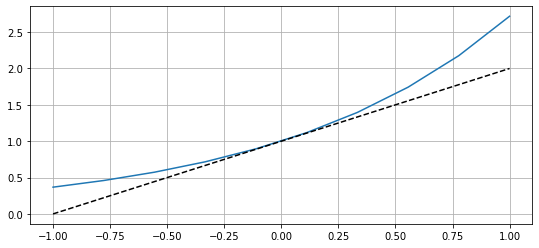

In [19]:
import matplotlib.pyplot as plt

t = np.linspace(-1, 1, 10)
plt.plot(t, np.exp(t))
t = np.linspace(-1, 1, 2)
plt.plot(t,t+1, ls='--', c='k');

You can see that the slope is very close to the curve at $t=0.1$, but far from it
at $t=1$. But let's continue with a step size of 1 for a moment. We can see that at $t=1$ the estimated value of $y$ is 2. Now we can compute the value at $t=2$ by taking the slope of the curve at $t=1$ and adding it to our initial estimate. The slope is computed with $y'=y$, so the slope is 2.

你可以看到斜率非常接近 $t=0.1$ 处的曲线，但离它很远
在 $t=1$。但是，让我们继续步长为 1 的情况。我们可以看到在 $t=1$ 时 $y$ 的估计值为 2。现在我们可以通过在 $t=1$ 处获取曲线的斜率并将其添加到我们的初步估计。斜率是用 $y'=y$ 计算的，所以斜率为 2。


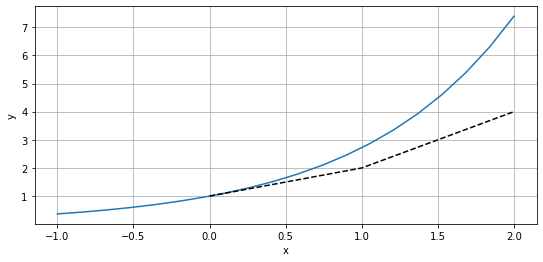

In [20]:
import kf_book.book_plots as book_plots

t = np.linspace(-1, 2, 20)
plt.plot(t, np.exp(t))
t = np.linspace(0, 1, 2)
plt.plot([1, 2, 4], ls='--', c='k')
book_plots.set_labels(x='x', y='y');

Here we see the next estimate for y is 4. The errors are getting large quickly, and you might be unimpressed. But 1 is a very large step size. Let's put this algorithm in code, and verify that it works by using a small step size.

在这里，我们看到 y 的下一个估计值是 4。误差很快就会变大，你可能不为所动。但是 1 是一个非常大的步长。让我们将此算法放入代码中，并通过使用小步长来验证它是否有效。


In [21]:
def euler(t, tmax, y, dx, step=1.):
    ys = []
    while t < tmax:
        y = y + step*dx(t, y)
        ys.append(y)
        t +=step        
    return ys

In [22]:
def dx(t, y): return y

print(euler(0, 1, 1, dx, step=1.)[-1])
print(euler(0, 2, 1, dx, step=1.)[-1])

2.0
4.0


This looks correct. So now let's plot the result of a much smaller step size.

这看起来是正确的。所以现在让我们绘制一个小得多的步长的结果。


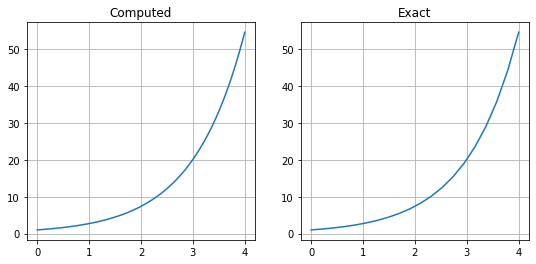

In [23]:
ys = euler(0, 4, 1, dx, step=0.00001)
plt.subplot(1,2,1)
plt.title('Computed')
plt.plot(np.linspace(0, 4, len(ys)),ys)
plt.subplot(1,2,2)
t = np.linspace(0, 4, 20)
plt.title('Exact')
plt.plot(t, np.exp(t));

In [24]:
print('exact answer=', np.exp(4))
print('euler answer=', ys[-1])
print('difference =', np.exp(4) - ys[-1])
print('iterations =', len(ys))

exact answer= 54.598150033144236
euler answer= 54.59705808834125
difference = 0.0010919448029866885
iterations = 400000


Here we see that the error is reasonably small, but it took a very large number of iterations to get three digits of precision. In practice Euler's method is too slow for most problems, and we use more sophisticated methods.

在这里，我们看到误差相当小，但需要大量的迭代才能获得三位数的精度。在实践中，欧拉的方法对于大多数问题来说太慢了，我们使用更复杂的方法。

Before we go on, let's formally derive Euler's method, as it is the basis for the more advanced Runge Kutta methods used in the next section. In fact, Euler's method is the simplest form of Runge Kutta.

在继续之前，让我们正式推导出 Euler 方法，因为它是下一节中使用的更高级的 Runge Kutta 方法的基础。事实上，欧拉方法是龙格库塔的最简单形式。

Here are the first 3 terms of the Taylor expansion of $y$. An infinite expansion would give an exact answer, so $O(h^4)$ denotes the error due to the finite expansion.

这是 $y$ 的泰勒展开式的前 3 项。无限展开会给出准确的答案，因此 $O(h^4)$ 表示由于有限展开导致的误差。

$$y(t_0 + h) = y(t_0) + h y'(t_0) + \frac{1}{2!}h^2 y''(t_0) + \frac{1}{3!}h^3 y'''(t_0) +  O(h^4)$$

Here we can see that Euler's method is using the first two terms of the Taylor expansion. Each subsequent term is smaller than the previous terms, so we are assured that the estimate will not be too far off from the correct value.

在这里我们可以看到欧拉的方法是使用泰勒展开式的前两项。每个后续项都小于前一项，因此我们确信估计值不会与正确值相差太远。


### Runge Kutta Methods
### 龙格-库塔方法

Runge Kutta is the workhorse of numerical integration. There are a vast number of methods in the literature. In practice, using the Runge Kutta algorithm that I present here will solve most any problem you will face. It offers a very good balance of speed, precision, and stability, and it is the 'go to' numerical integration method unless you have a very good reason to choose something different.

Runge Kutta 是数值积分的主力军。文献中有大量的方法。在实践中，使用我在这里介绍的 Runge Kutta 算法将解决你将面临的大多数问题。它在速度、精度和稳定性方面提供了非常好的平衡，并且它是“首选”数值积分方法，除非你有充分的理由选择不同的方法。

Let's dive in. We start with some differential equation

让我们开始吧。我们从一些微分方程开始

$$\ddot{y} = \frac{d}{dt}\dot{y}$$.

We can substitute the derivative of y with a function f, like so

我们可以用函数 f 代替 y 的导数，就像这样

$$\ddot{y} = \frac{d}{dt}f(y,t)$$.

Deriving these equations is outside the scope of this book, but the Runge Kutta RK4 method is defined with these equations.

推导这些方程超出了本书的范围，但使用这些方程定义了 Runge Kutta RK4 方法。

$$y(t+\Delta t) = y(t) + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4) + O(\Delta t^4)$$

$$\begin{aligned}
k_1 &= f(y,t)\Delta t \\
k_2 &= f(y+\frac{1}{2}k_1, t+\frac{1}{2}\Delta t)\Delta t \\
k_3 &= f(y+\frac{1}{2}k_2, t+\frac{1}{2}\Delta t)\Delta t \\
k_4 &= f(y+k_3, t+\Delta t)\Delta t
\end{aligned}
$$

Here is the corresponding code:

下面是对应的代码：


In [25]:
def runge_kutta4(y, x, dx, f):
    """computes 4th order Runge-Kutta for dy/dx.
    y is the initial value for y
    x is the initial value for x
    dx is the difference in x (e.g. the time step)
    f is a callable function (y, x) that you supply 
    to compute dy/dx for the specified values.
    """
    
    k1 = dx * f(y, x)
    k2 = dx * f(y + 0.5*k1, x + 0.5*dx)
    k3 = dx * f(y + 0.5*k2, x + 0.5*dx)
    k4 = dx * f(y + k3, x + dx)
    
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6.

Let's use this for a simple example. Let

让我们用它来做一个简单的例子。让

$$\dot{y} = t\sqrt{y(t)}$$

with the initial values

具有初始值


$$\begin{aligned}t_0 &= 0\\y_0 &= y(t_0) = 1\end{aligned}$$


max error 0.00005


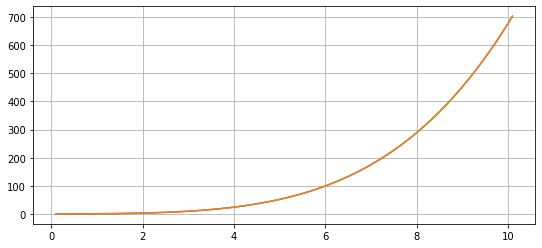

In [26]:
import math
import numpy as np
t = 0.
y = 1.
dt = .1

ys, ts = [], []

def func(y,t):
    return t*math.sqrt(y)

while t <= 10:
    y = runge_kutta4(y, t, dt, func)
    t += dt
    ys.append(y)
    ts.append(t)

exact = [(t**2 + 4)**2 / 16. for t in ts]
plt.plot(ts, ys)
plt.plot(ts, exact)

error = np.array(exact) - np.array(ys)
print(f"max error {max(error):.5f}")

## Bayesian Filtering
## 7.7 贝叶斯滤波

Starting in the Discrete Bayes chapter I used a Bayesian formulation for filtering. Suppose we are tracking an object. We define its *state* at a specific time as its position, velocity, and so on. For example, we might write the state at time $t$ as $\mathbf x_t = \begin{bmatrix}x_t &\dot x_t \end{bmatrix}^\mathsf T$.

从离散贝叶斯一章开始，我使用贝叶斯公式进行滤波。假设我们正在跟踪一个对象。我们将它在特定时间的*状态*定义为它的位置、速度等。例如，我们可以将时间 $t$ 的状态写为 $\mathbf x_t = \begin{bmatrix}x_t &\dot x_t \end{bmatrix}^\mathsf T$。

When we take a measurement of the object we are measuring the state or part of it. Sensors are noisy, so the measurement is corrupted with noise. Clearly though, the measurement is determined by the state. That is, a change in state may change the measurement, but a change in measurement will not change the state.

当我们测量对象时，我们正在测量它的状态或部分状态。传感器有噪声，因此测量值被噪声破坏。显然，测量是由状态决定的。也就是说，状态的变化可能会改变测量，但测量的变化不会改变状态。

In filtering our goal is to compute an optimal estimate for a set of states $\mathbf x_{0:t}$ from time 0 to time $t$. If we knew $\mathbf x_{0:t}$ then it would be trivial to compute a set of measurements $\mathbf z_{0:t}$ corresponding to those states. However, we receive a set of measurements $\mathbf z_{0:t}$, and want to compute the corresponding states $\mathbf x_{0:t}$. This is called *statistical inversion* because we are trying to compute the input from the output.

在滤波时，我们的目标是计算从时间 0 到时间 $t$ 的一组状态 $\mathbf x_{0:t}$ 的最优估计。如果我们知道 $\mathbf x_{0:t}$，那么计算一组对应于这些状态的测量值 $\mathbf z_{0:t}$ 将是微不足道的。但是，我们收到一组测量值 $\mathbf z_{0:t}$，并想要计算相应的状态 $\mathbf x_{0:t}$。这被称为*统计反演*，因为我们试图从输出中计算输入。

Inversion is a difficult problem because there is typically no unique solution. For a given set of states $\mathbf x_{0:t}$ there is only one possible set of measurements (plus noise), but for a given set of measurements there are many different sets of states that could have led to those measurements.

反演是一个难题，因为通常没有唯一的解决方案。对于给定的一组状态 $\mathbf x_{0:t}$，只有一组可能的测量值（加上噪声），但对于给定的一组测量值，有许多不同的状态组可能导致这些测量值。

Recall Bayes Theorem:

回忆贝叶斯定理：

$$P(x \mid z) = \frac{P(z \mid x)P(x)}{P(z)}$$

where $P(z \mid x)$ is the *likelihood* of the measurement $z$, $P(x)$ is the *prior* based on our process model, and $P(z)$ is a normalization constant. $P(x \mid z)$ is the *posterior*, or the distribution after incorporating the measurement $z$, also called the *evidence*.

其中 $P(z \mid x)$ 是测量 $z$ 的*似然*，$P(x)$ 是基于我们的过程模型的*先验*，$P(z)$ 是归一化常数。$P(x \mid z)$ 是*后验*，或合并测量 $z$ 后的分布，也称为*证据*。

This is a *statistical inversion* as it goes from $P(z \mid x)$ to $P(x \mid z)$. The solution to our filtering problem can be expressed as:

这是一个*统计反演*，因为它从 $P(z \mid x)$ 到 $P(x \mid z)$。我们的滤波问题的解决方案可以表示为：

$$P(\mathbf x_{0:t} \mid \mathbf z_{0:t}) = \frac{P(\mathbf z_{0:t} \mid \mathbf x_{0:t})P(\mathbf x_{0:t})}{P(\mathbf z_{0:t})}$$

That is all well and good until the next measurement $\mathbf z_{t+1}$ comes in, at which point we need to recompute the entire expression for the range $0:t+1$.

这一切都很好，直到下一次测量 $\mathbf z_{t+1}$ 出现，此时我们需要重新计算范围 $0:t+1$ 的整个表达式。

In practice this is intractable because we are trying to compute the posterior distribution $P(\mathbf x_{0:t} \mid \mathbf z_{0:t})$ for the state over the full range of time steps. But do we really care about the probability distribution at the third step (say) when we just received the tenth measurement? Not usually. So we relax our requirements and only compute the distributions for the current time step.

在实践中，这是难以解决的，因为我们试图在整个时间步长范围内计算状态的后验分布 $P(\mathbf x_{0:t} \mid \mathbf z_{0:t})$。但是当我们刚刚收到第十次测量时，我们真的关心第三步（比如说）的概率分布吗？通常不会。所以我们放宽我们的要求，只计算当前时间步的分布。

The first simplification is we describe our process (e.g., the motion model for a moving object) as a *Markov chain*. That is, we say that the current state is solely dependent on the previous state and a transition probability $P(\mathbf x_k \mid \mathbf x_{k-1})$, which is just the probability of going from the last state to the current one. We write:

第一个简化是我们将我们的过程（例如，移动物体的运动模型）描述为*马尔可夫链*。也就是说，我们说当前状态完全依赖于前一个状态和一个转移概率 $P(\mathbf x_k \mid \mathbf x_{k-1})$，也就是从上一个状态到当前状态的概率。我们写：

$$\mathbf x_k \sim P(\mathbf x_k \mid \mathbf x_{k-1})$$

In practice this is extremely reasonable, as many things have the *Markov property*. If you are driving in a parking lot, does your position in the next second depend on whether you pulled off the interstate or were creeping along on a dirt road one minute ago? No. Your position in the next second depends solely on your current position, speed, and control inputs, not on what happened a minute ago. Thus, cars have the Markov property, and we can make this simplification with no loss of precision or generality.

在实践中这是非常合理的，因为许多事物都具有*马尔可夫属性*。如果你在停车场开车，你下一秒的位置是否取决于你是从州际公路上下来还是在一分钟前在土路上爬行？不，你下一秒的位置完全取决于你当前的位置、速度和控制输入，而不是一分钟前发生的事情。因此，汽车具有马尔可夫性质，我们可以在不损失精确性或一般性的情况下进行这种简化。

The next simplification we make is do define the *measurement model* as depending on the current state $\mathbf x_k$ with the conditional probability of the measurement given the current state: $P(\mathbf z_k \mid \mathbf x_k)$. We write:

我们进行的下一个简化是将*测量模型*定义为取决于当前状态 $\mathbf x_k$ 的条件概率：$P(\mathbf z_k \mid \mathbf x_k)$。我们写：

$$\mathbf z_k \sim P(\mathbf z_k \mid \mathbf x_k)$$

We have a recurrence now, so we need an initial condition to terminate it. Therefore we say that the initial distribution is the probablity of the state $\mathbf x_0$:

我们现在有一个递归，所以我们需要一个初始条件来终止它。因此我们说初始分布是状态 $\mathbf x_0$ 的概率：

$$\mathbf x_0 \sim P(\mathbf x_0)$$

These terms are plugged into Bayes equation. If we have the state $\mathbf x_0$ and the first measurement we can estimate $P(\mathbf x_1 | \mathbf z_1)$. The motion model creates the prior $P(\mathbf x_2 \mid \mathbf x_1)$. We feed this back into Bayes theorem to compute $P(\mathbf x_2 | \mathbf z_2)$. We continue this predictor-corrector algorithm, recursively computing the state and distribution at time $t$ based solely on the state and distribution at time $t-1$ and the measurement at time $t$.

这些项被插入贝叶斯方程。如果我们有状态 $\mathbf x_0$ 和第一次测量，我们可以估计 $P(\mathbf x_1 | \mathbf z_1)$。运动模型创建了先验 $P(\mathbf x_2 \mid \mathbf x_1)$。我们将其反馈给贝叶斯定理以计算 $P(\mathbf x_2 | \mathbf z_2)$。我们继续这种预测-校正算法，仅基于时间 $t-1$ 的状态和分布以及时间 $t$ 的测量值递归地计算时间 $t$ 的状态和分布。

The details of the mathematics for this computation varies based on the problem. The **Discrete Bayes** and **Univariate Kalman Filter** chapters gave two different formulations which you should have been able to reason through. The univariate Kalman filter assumes that for a scalar state both the noise and process are linear model are affected by zero-mean, uncorrelated Gaussian noise.

此计算的数学细节因问题而异。**离散贝叶斯**和**单变量卡尔曼滤波器**章节给出了两种不同的公式，你应该能够推理出来。单变量卡尔曼滤波器假设对于标量状态，噪声和过程都是线性模型，均受零均值、不相关的高斯噪声影响。

The Multivariate Kalman filter makes the same assumption but for states and measurements that are vectors, not scalars. Dr. Kalman was able to prove that if these assumptions hold true then the Kalman filter is *optimal* in a least squares sense. Colloquially this means there is no way to derive more information from the noisy measurements. In the remainder of the book I will present filters that relax the constraints on linearity and Gaussian noise.

多元卡尔曼滤波器做出相同的假设，但状态和测量是向量，而不是标量。卡尔曼博士能够证明，如果这些假设成立，那么卡尔曼滤波器在最小二乘意义上是*最优的*。通俗地说，这意味着无法从噪声测量中获得更多信息。在本书的其余部分，我将介绍放松对线性和高斯噪声约束的滤波器。

Before I go on, a few more words about statistical inversion. As Calvetti and Somersalo write in *Introduction to Bayesian Scientific Computing*, "we adopt the Bayesian point of view: *randomness simply means lack of information*"[3]. Our state parameterizes physical phenomena that we could in principle measure or compute: velocity, air drag, and so on. We lack enough information to compute or measure their value, so we opt to consider them as random variables. Strictly speaking they are not random, thus this is a subjective position.

在继续之前，我还要多说几句关于统计反演的内容。正如 Calvetti 和 Somersalo 在*贝叶斯科学计算简介*中所写，“我们采用贝叶斯观点：*随机性只是意味着缺乏信息*”[3]。我们的状态参数化了我们原则上可以测量或计算的物理现象：速度、空气阻力等。我们缺乏足够的信息来计算或测量它们的值，因此我们选择将它们视为随机变量。严格来说它们不是随机的，因此这是一个主观的立场。

They devote a full chapter to this topic. I can spare a paragraph. Bayesian filters are possible because we ascribe statistical properties to unknown parameters. In the case of the Kalman filter we have closed-form solutions to find an optimal estimate. Other filters, such as the discrete Bayes filter or the particle filter which we cover in a later chapter, model the probability in a more ad-hoc, non-optimal manner. The power of our technique comes from treating lack of information as a random variable, describing that random variable as a probability distribution, and then using Bayes Theorem to solve the statistical inference problem.

他们用一整章的篇幅来讨论这个主题。我可以留一段。贝叶斯滤波器是可能的，因为我们将统计属性归因于未知参数。在卡尔曼滤波器的情况下，我们有封闭形式的解决方案来找到最佳估计。其他滤波器，例如离散贝叶斯滤波器或我们在后面章节中介绍的粒子滤波器，以一种更加特别的、非最优的方式对概率进行建模。我们技术的强大之处在于将缺乏信息视为随机变量，将该随机变量描述为概率分布，然后使用贝叶斯定理解决统计推断问题。


## Converting Kalman Filter to a g-h Filter
## 将卡尔曼滤波器转换为 g-h 滤波器

I've stated that the Kalman filter is a form of the g-h filter. It just takes some algebra to prove it. It's more straightforward to do with the one dimensional case, so I will do that. Recall

我已经说过卡尔曼滤波器是 g-h 滤波器的一种形式。只需要一些代数来证明它。使用一维情况更简单，所以我会这样做。记起

$$
\mu_{x}=\frac{\sigma_1^2 \mu_2 + \sigma_2^2 \mu_1} {\sigma_1^2 + \sigma_2^2}
$$

which I will make more friendly for our eyes as:

我会让我们的眼睛更友好：

$$
\mu_{x}=\frac{ya + xb} {a+b}
$$

We can easily put this into the g-h form with the following algebra

我们可以使用以下代数轻松将其转换为 g-h 形式

$$ 
\begin{aligned}
\mu_{x}&=(x-x) + \frac{ya + xb} {a+b} \\
\mu_{x}&=x-\frac{a+b}{a+b}x  + \frac{ya + xb} {a+b} \\ 
\mu_{x}&=x +\frac{-x(a+b) + xb+ya}{a+b} \\
\mu_{x}&=x+ \frac{-xa+ya}{a+b}  \\
\mu_{x}&=x+ \frac{a}{a+b}(y-x)\\
\end{aligned}
$$

We are almost done, but recall that the variance of estimate is given by

我们几乎完成了，但请记住，估计的方差由下式给出

$$\begin{aligned}
\sigma_{x}^2 &= \frac{1}{\frac{1}{\sigma_1^2} +  \frac{1}{\sigma_2^2}} \\
&= \frac{1}{\frac{1}{a} +  \frac{1}{b}}
\end{aligned}$$

We can incorporate that term into our equation above by observing that

我们可以将这个项纳入上面的方程，注意到

$$
\begin{aligned}
\frac{a}{a+b} &= \frac{a/a}{(a+b)/a} = \frac{1}{(a+b)/a}  \\
 &= \frac{1}{1 + \frac{b}{a}} = \frac{1}{\frac{b}{b} + \frac{b}{a}}  \\
 &= \frac{1}{b}\frac{1}{\frac{1}{b} + \frac{1}{a}} \\
 &= \frac{\sigma^2_{x}}{b}
 \end{aligned}
$$

We can tie all of this together with

我们可以将所有这些联系在一起

$$
\begin{aligned}
\mu_{x}&=x+ \frac{a}{a+b}(y-x) \\
&= x + \frac{\sigma^2_{x}}{b}(y-x) \\
&= x + g_n(y-x)
\end{aligned}
$$

where

其中

$$g_n = \frac{\sigma^2_{x}}{\sigma^2_{y}}$$

The end result is multiplying the residual of the two measurements by a constant and adding to our previous value, which is the $g$ equation for the g-h filter. $g$ is the variance of the new estimate divided by the variance of the measurement. Of course in this case $g$ is not a constant as it varies with each time step as the variance changes. We can also derive the formula for $h$ in the same way. It is not a particularly illuminating derivation and I will skip it. The end result is

最终结果是将两个测量值的残差乘以一个常数并添加到我们之前的值，即 g-h 滤波器的 $g$ 方程。$g$ 是新估计的方差除以测量的方差。当然，在这种情况下，$g$ 不是一个常数，因为它随着方差的变化而随着每个时间步长而变化。我们也可以用同样的方法推导出 $h$ 的公式。这不是一个特别有启发性的推导，我将跳过它。最终结果是

$$h_n = \frac{COV (x,\dot x)}{\sigma^2_{y}}$$

The takeaway point is that $g$ and $h$ are specified fully by the variance and covariances of the measurement and predictions at time $n$. In other words, we are picking a point between the measurement and prediction by a scale factor determined by the quality of each of those two inputs.

要点是 $g$ 和 $h$ 完全由时间 $n$ 的测量和预测的方差和协方差指定。换句话说，我们通过由这两个输入中的每一个的质量确定的比例因子在测量和预测之间选择一个点。


## References
## 参考文献

 * [1] C.B. Molwer and C.F. Van Loan "Nineteen Dubious Ways to Compute the Exponential of a Matrix, Twenty-Five Years Later,", *SIAM Review 45, 3-49*. 2003.

 * [2] C.F. van Loan, "Computing Integrals Involving the Matrix Exponential," IEEE *Transactions Automatic Control*, June 1978.

 * [3] Calvetti, D and Somersalo E, "Introduction to Bayesian Scientific Computing: Ten Lectures on Subjective Computing,", *Springer*, 2007.

 * [4] Brown, R. G. and Hwang, P. Y.C., "Introduction to Random Signals and Applied Kalman Filtering", *Wiley and Sons*, Fourth Edition, p.143-147, 2012.
